In [1]:
%pip install snntorch
import torch
import torch.nn as nn
import glob
from torch.nn.functional import cross_entropy
import torch.nn.functional as F
import snntorch as snn
from snntorch import spikegen
from snntorch import surrogate
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import gc
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


Note: you may need to restart the kernel to use updated packages.


In [2]:

class LOBDayDataset(Dataset):
    """Loads a single day file from the FI-2010 dataset without cross-day leakage"""
    def __init__(self, filepath, window_size=30, stride=5, delta_threshold=0.005):
        
        data = np.loadtxt(filepath)
        features = data[:144, :].T  # features
        labels = data[146, :].T - 1 # labels (we map them from {1, 2, 3...} to {0, 1, 2, 3.....})
        del data

        features_tensor = torch.from_numpy(features).float()
        labels_tensor = torch.from_numpy(labels).long()
        del features, labels

        # spike encoding using delta modulation see https://snntorch.readthedocs.io/en/latest/tutorials/legacy/tutorial_1_old.html#delta-modulation
        spike = spikegen.delta(features_tensor, threshold=delta_threshold, padding=True, off_spike=True)
        spikes_pos = torch.where(spike > 0, spike, torch.zeros_like(spike))
        spikes_neg = torch.where(spike < 0, torch.abs(spike), torch.zeros_like(spike))
        del spike, features_tensor

        # inputs <= spike_pos + spike_neg
        inputs = torch.cat((spikes_pos, spikes_neg), dim=1).half() 
        del spikes_pos, spikes_neg

        
        
        # we slice the inputs into sequence windows 
        self.X, self.Y = self._create_sequences(inputs, labels_tensor, window_size, stride)
        del inputs, labels_tensor
        gc.collect()
    
    # create sequence of the inputs based on window_size and stride
    def _create_sequences(self, inputs, labels, window_size, stride):
        X, Y = [], []
        for i in range(0, len(inputs) - window_size, stride):
            X.append(inputs[i : i + window_size])
            Y.append(labels[i + window_size - 1])
        return torch.stack(X), torch.stack(Y)

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.X[idx].float(), self.Y[idx]

# this function implements the paper exact anchred cross-validation protocol
# example: for a fold of 2 (fold_idx = 2)
# we train the MSNN on day 1 + day 2 and test the MSNN on day 3 data  
def get_anchored_fold_loaders(fold_idx, train_files, test_files, batch_size=256):
    print(f"\n***  fold == {fold_idx + 1} ***")
    
    # identify the days for the training 
    active_train_files = train_files[:fold_idx + 1]
    # The test target is always the next sequential day window
    active_test_file = test_files[fold_idx + 1]
    
    print(f"training files are up to: {active_train_files[-1].split('/')[-1]}")
    print(f"testing file: {active_test_file.split('/')[-1]}")
    
    train_datasets = [LOBDayDataset(f) for f in active_train_files]
    train_dataset = torch.utils.data.ConcatDataset(train_datasets)

    test_dataset = LOBDayDataset(active_test_file)
    
    
    
    # set shuffle=False to preserve internal temporal sequence blocks
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
    
    return train_loader, test_loader, train_dataset

In [3]:

def weights(device, labels, smoothing=.15):
    class_counts = torch.bincount(labels.long())
    total_samples = len(labels)
    
    smoothed_c = class_counts.float() + (smoothing * total_samples / len(class_counts))
    dynamic_weights = total_samples / (len(class_counts) * smoothed_c)
    print(dynamic_weights)
    return dynamic_weights.to(device=device)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha  # weights
        self.gamma = gamma 
        self.reduction = reduction
    
    def forward(self, logits, targets):
        ce_loss = cross_entropy(logits, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_weight = (1 - pt) ** self.gamma  
        loss = focal_weight * ce_loss
        
        if self.reduction == 'mean':
            return loss.mean()
        return loss.sum()

class STEQuantize(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, num_levels):
        if num_levels is None or num_levels <= 1:
            return x
        scaled = x * (num_levels - 1)
        quantized = torch.round(scaled)
        return quantized / (num_levels - 1)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None

# Hardware-aware RRAM crossbar with: 
# Differential conductance mapping 
# Stuck at fauls (SAF)
# Cycle-to-cyle variation
# Device-to-Device variation
# Retention Drift    
class MemristorCrossbar(nn.Module):
    def __init__(self, in_features, out_features, num_levels=16, saf_rate=0.03, noise_std=0.05, 
                d2d_std=0.05,
                drift_rate=0.002,
                force_ideal=False,
                force_noise_eval=False
                ):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        
        if force_ideal:
            num_levels = 0
            saf_rate = 0.0
            noise_std = 0.0
            d2d_std = 0.0
            drift_rate = 0.0
            print(f"params memristor: {num_levels }, {saf_rate}, {noise_std}, {d2d_std}, {drift_rate}")
            
        self.num_levels = num_levels
        self.noise_std = noise_std
        self.d2d_std = d2d_std
        self.force_ideal = force_ideal
        self.drift_rate = drift_rate
        self.force_noise_eval = force_noise_eval
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))
        
        nn.init.normal_(self.weight, mean=0.0, std=0.05)
        nn.init.zeros_(self.bias)

      
        self.register_buffer("saf_pos_lrs", torch.rand(out_features, in_features) < (saf_rate / 2))
        self.register_buffer("saf_pos_hrs", torch.rand(out_features, in_features) < (saf_rate / 2))
        self.register_buffer("saf_neg_lrs", torch.rand(out_features, in_features) < (saf_rate / 2))
        self.register_buffer("saf_neg_hrs",torch.rand(out_features, in_features) < (saf_rate / 2))

       # Device-to-Device variation D2D
        self.register_buffer("d2d_pos", torch.clamp( 1.0 + torch.randn(out_features, in_features) * d2d_std, 0.7, 1.3))
        self.register_buffer("d2d_neg", torch.clamp( 1.0 + torch.randn(out_features, in_features) * d2d_std, 0.7, 1.3))

    def get_hardware_weights(self):

        # weights normalized
        weight_scale = torch.max(torch.abs(self.weight)).detach().clamp(min=1e-5)
        w_norm = torch.clamp(self.weight / weight_scale, -1.0, 1.0)
        g_pos = (w_norm + 1.0) / 2.0
        g_neg = (1.0 - w_norm) / 2.0
        
        g_pos *= self.d2d_pos
        g_neg *= self.d2d_neg
        
        g_pos = torch.clamp(g_pos, 0.0, 1.0)
        g_neg = torch.clamp(g_neg, 0.0, 1.0)

        # stuch at faults (SAF)
        g_pos = torch.where(self.saf_pos_lrs, torch.ones_like(g_pos), g_pos)
        g_pos = torch.where(self.saf_pos_hrs, torch.zeros_like(g_pos), g_pos)
        g_neg = torch.where(self.saf_neg_lrs, torch.ones_like(g_neg), g_neg)
        g_neg = torch.where(self.saf_neg_hrs, torch.zeros_like(g_neg), g_neg)
        # qunatization
        g_pos_q = STEQuantize.apply(g_pos, self.num_levels)
        g_neg_q = STEQuantize.apply(g_neg, self.num_levels)
       
        #C2C cycle to cycle
        if (self.training or self.force_noise_eval) and self.noise_std > 0:
            g_pos_q = torch.clamp(g_pos_q + torch.randn_like(g_pos_q) * self.noise_std, 0.0, 1.0)
            g_neg_q = torch.clamp(g_neg_q + torch.randn_like(g_neg_q) * self.noise_std, 0.0, 1.0)

        # retention drift
        if not self.training:
            drift = torch.exp(torch.full_like(g_pos_q, -self.drift_rate))
            g_pos_q *= drift
            g_neg_q *= drift
        w_hardware = (g_pos_q - g_neg_q) * weight_scale
        
        return w_hardware

    def forward(self, x):
        w_hardware = self.get_hardware_weights()
        return F.linear(x, w_hardware, self.bias)
    
    
class MSNN(nn.Module):
    """hardware-constrained MSNN and tracking spike metrics"""
    def __init__(self, num_inputs=288, num_hidden=128, num_outputs=3, beta=0.9, num_levels=16, saf_rate=0.03, noise_std=0.05, force_ideal=False, force_noise_eval=False):
        super().__init__()
        spike_grad = surrogate.fast_sigmoid(slope=25)
        
        self.fc1 = MemristorCrossbar(num_inputs, num_hidden, num_levels, saf_rate, noise_std, force_ideal=force_ideal, force_noise_eval=force_noise_eval)
        self.lif1 = snn.Leaky(threshold=0.5, beta=beta, spike_grad=spike_grad, reset_mechanism="subtract")
        self.drop = nn.Dropout(0.3) 
        
        self.fc2 = MemristorCrossbar(num_hidden, num_outputs, num_levels, saf_rate, noise_std, force_ideal=force_ideal, force_noise_eval=force_noise_eval)
        self.lif2 = snn.Leaky(threshold=1.0, beta=beta, spike_grad=spike_grad, reset_mechanism="subtract")
        
        # keep track of spike counts
        self.spike_counts = {"layer1": 0.0, "layer2": 0.0, "total_steps": 0}

    def reset_spike_metrics(self):
        self.spike_counts = {"layer1": 0.0, "layer2": 0.0, "total_steps": 0}

    def forward(self, x):
        # adjust the input shame from (batch, time, featurres) ->> (time, batch, features)
        x = x.permute(1, 0, 2)
        batch_size = x.shape[1]
        time_steps = x.shape[0]
        
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        
        # input current is calculated in a single vectorized operation
        cur1_all = self.fc1(x)
        
        # Cache Layer 2 hardware matrix weights for this specific forward timeline execution block
        w_phys2 = self.fc2.get_hardware_weights()
        bias2 = self.fc2.bias
        
        for step in range(time_steps):
            spk1, mem1 = self.lif1(cur1_all[step], mem1)
            spk1_dropped = self.drop(spk1)
            
            # record layer 1 spike track
            if not self.training:
                self.spike_counts["layer1"] += spk1.detach().sum().item()
            
            cur2 = F.linear(spk1_dropped, w_phys2, bias2)
            spk2, mem2 = self.lif2(cur2, mem2)
            
            # record layer 2 spike track
            if not self.training:
                self.spike_counts["layer2"] += spk2.detach().sum().item()
                
        if not self.training:
            self.spike_counts["total_steps"] += (batch_size * time_steps)
            
        return mem2



In [4]:
def compute_hardware_metrics(data_loader, net, device, window_size=30):
    """evaluates the model and computes hardware metrics etc...
        window_size is a must, unless if its 30
    """
    net.eval()
    net.reset_spike_metrics()
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, targets in data_loader:
            data = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).long()
            logits = net(data)
            preds = logits.argmax(dim=1)
            
            correct += (preds == targets).sum().item()
            total += targets.size(0)
            
    # calculates sparsity metrics
    total_samples_processed = net.spike_counts["total_steps"] / window_size  
    total_neuron_steps_l1 = net.spike_counts["total_steps"] * net.fc1.out_features
    total_neuron_steps_l2 = net.spike_counts["total_steps"] * net.fc2.out_features
    
    l1_sparsity = net.spike_counts["layer1"] / max(1, total_neuron_steps_l1)
    l2_sparsity = net.spike_counts["layer2"] / max(1, total_neuron_steps_l2)
    
    accuracy = correct / total
    
    print("\n*** extracted hardware metrics ***")
    print(f"accuracy: {accuracy*100:.2f}%")
    print(f"layer 1 firing density : {l1_sparsity*100:.3f}% spikes/neuron/step")
    print(f"layer 2 firing density : {l2_sparsity*100:.3f}% spikes/neuron/step")
    print(f"total spikes emitted per sequence window ({window_size}): {(net.spike_counts['layer1'] + net.spike_counts['layer2']) / max(1, total_samples_processed):.2f}")
    
    return {
        "accuracy": accuracy,
        "l1_sparsity": l1_sparsity,
        "l2_sparsity": l2_sparsity,
    }


In [5]:
import torch
import numpy as np
import os

num_epochs = 20  #significantly lower as anchored dataset scale up easily
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# update with ur own paths 
train_files = sorted(glob.glob(
    "/kaggle/input/datasets/firmwired/fi-2010/data/published/BenchmarkDatasets/BenchmarkDatasets/BenchmarkDatasets/NoAuction/NoAuction_MinMax/NoAuction_MinMax_Training/Train_Dst_NoAuction_MinMax_CF_*.txt"
))
test_files = sorted(glob.glob(
    "/kaggle/input/datasets/firmwired/fi-2010/data/published/BenchmarkDatasets/BenchmarkDatasets/BenchmarkDatasets/NoAuction/NoAuction_MinMax/NoAuction_MinMax_Testing/Test_Dst_NoAuction_MinMax_CF_*.txt"
))

output_dir = '/kaggle/working/MSNN/noisy'
os.makedirs(output_dir, exist_ok=True)
torch.manual_seed(123)
fold_summary_metrics = []

net = MSNN(
    num_inputs=288, 
    num_hidden=128, 
    num_outputs=3, 
    beta=0.9, 
    num_levels=16, 
    saf_rate=0.03, 
    noise_std=0.05,
    force_ideal=False,
    force_noise_eval=True
).to(device)


# loop across all 9 files
for fold_idx in range(8):
    print("\n" + "*"*70)
    print(f"* anchord fold  {fold_idx + 1} / 9 *")
    print("*"*70)
    
    # get the needed fold time (based on fold_idx)
    train_loader, test_loader, fold_train_dataset = get_anchored_fold_loaders(
        fold_idx=fold_idx, 
        train_files=train_files, 
        test_files=test_files, 
        batch_size=256
    )
    
    if isinstance(fold_train_dataset, torch.utils.data.ConcatDataset):
        active_labels = torch.cat([ds.Y for ds in fold_train_dataset.datasets])
    else:
        active_labels = fold_train_dataset.Y
        
    w = weights(device=device, labels=active_labels)
    loss_fn = FocalLoss(alpha=w, gamma=2)
    
   
    num_epochs_per_fold = 10  
    optimizer = torch.optim.Adam(net.parameters(), lr=3e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs_per_fold, eta_min=1e-6)
    
    best_fold_acc = 0.0
    patience_counter = 0
    patience = 4
    
    # training loop
    for epoch in range(num_epochs_per_fold):
        net.train()
        epoch_loss = 0.0
        
        for batch_idx, (data, targets) in enumerate(train_loader):
            data = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).long()
            
            optimizer.zero_grad(set_to_none=True)
            logits = net(data)
            loss_val = loss_fn(logits, targets)
            
            loss_val.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss_val.item()
            
        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        
        net.eval()
        with torch.no_grad():
            val_correct = 0
            val_total = 0
            for val_data, val_targets in test_loader:
                val_data = val_data.to(device, non_blocking=True)
                val_targets = val_targets.to(device, non_blocking=True).long()
                
                val_preds = net(val_data).argmax(dim=1)
                val_correct += (val_preds == val_targets).sum().item()
                val_total += val_targets.size(0)
            current_val_acc = val_correct / max(1, val_total)
            
        print(f"Fold {fold_idx+1} | Epoch [{epoch+1}/{num_epochs_per_fold}] | Loss: {avg_loss:.4f} | Current Test Acc: {current_val_acc*100:.2f}%")
        
        if current_val_acc > best_fold_acc:
            best_fold_acc = current_val_acc
            patience_counter = 0
            torch.save(net.state_dict(), os.path.join(output_dir, f'model_{fold_idx+1}.pt'))
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("↳ Early stopping fold fine-tuning profile.")
                break
                
    # 4. Extract Final Hardware Profiling numbers for this fold's configuration
    print(f"\n--- Compiling Hardware Metrics for Fold {fold_idx + 1} ---") 
    checkpoint_file = os.path.join(output_dir, f'model_{fold_idx+1}.pt')
    net.load_state_dict(torch.load(checkpoint_file, map_location=device, weights_only=True))
    
    total_input_sparsity = 0.0
    num_batches = 0
    with torch.no_grad():
        for val_data, _ in test_loader:
            val_data = val_data.to(device, non_blocking=True)
            batch_density = val_data.float().mean().item()             
            total_input_sparsity += batch_density
            num_batches += 1
            
    fold_input_sparsity = total_input_sparsity / num_batches
    
    fold_profile = compute_hardware_metrics(test_loader, net, device)
    fold_summary_metrics.append({
        "fold": fold_idx + 1,
        "accuracy": fold_profile["accuracy"],
        "l1_sparsity": fold_profile["l1_sparsity"],
        "l2_sparsity": fold_profile["l2_sparsity"],
        "input_sparsity": fold_input_sparsity
    })

# 5. Output Summary Results Block for Paper Generation
print("\n" + "="*60)
print("final report:::")
print("="*60)
print(f"{'Fold':<6} | {'Test Accuracy':<15} | {'L1 Spike Density':<18} | {'L2 Spike Density':<18}")
print("-"*60)
for entry in fold_summary_metrics:
  print(f"{entry['fold']:<6} | "
          f"{entry['accuracy']*100:<14.2f}% | "
          f"{entry['input_sparsity']*100:<14.4f}% | "
          f"{entry['l1_sparsity']*100:<17.4f}% | "
          f"{entry['l2_sparsity']*100:<17.4f}%")
print("-"*60)

device: cuda

**********************************************************************
* anchord fold  1 / 9 *
**********************************************************************

***  fold == 1 ***
training files are up to: Train_Dst_NoAuction_MinMax_CF_1.txt
testing file: Test_Dst_NoAuction_MinMax_CF_2.txt


KeyboardInterrupt: 

In [6]:
output_dir_ideal = '/kaggle/working/MSNN/ideal'
os.makedirs(output_dir_ideal, exist_ok=True)

torch.manual_seed(123)
net_ideal = MSNN(
    num_inputs=288, 
    num_hidden=128, 
    num_outputs=3, 
    beta=0.9, 
    force_ideal=True
).to(device)
# net_ideal.force_noise_eval = True
fold_summary_metrics_ideal = []
# loop across all 9 files
for fold_idx in range(8):
    print("\n" + "*"*70)
    print(f"* anchord fold  {fold_idx + 1} / 9 *")
    print("*"*70)
    
    # get the needed fold time (based on fold_idx)
    train_loader, test_loader, fold_train_dataset = get_anchored_fold_loaders(
        fold_idx=fold_idx, 
        train_files=train_files, 
        test_files=test_files, 
        batch_size=256
    )
    
    if isinstance(fold_train_dataset, torch.utils.data.ConcatDataset):
        active_labels = torch.cat([ds.Y for ds in fold_train_dataset.datasets])
    else:
        active_labels = fold_train_dataset.Y
        
    w = weights(device=device, labels=active_labels)
    loss_fn = FocalLoss(alpha=w, gamma=2)
    
   
    num_epochs_per_fold = 10  
    optimizer = torch.optim.Adam(net_ideal.parameters(), lr=3e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs_per_fold, eta_min=1e-6)
    
    best_fold_acc = 0.0
    patience_counter = 0
    patience = 4
    
    # training loop
    for epoch in range(num_epochs_per_fold):
        net_ideal.train()
        epoch_loss = 0.0
        
        for batch_idx, (data, targets) in enumerate(train_loader):
            data = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).long()
            
            optimizer.zero_grad(set_to_none=True)
            logits = net_ideal(data)
            loss_val = loss_fn(logits, targets)
            
            loss_val.backward()
            torch.nn.utils.clip_grad_norm_(net_ideal.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss_val.item()
            
        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        
        net_ideal.eval()
        with torch.no_grad():
            val_correct = 0
            val_total = 0
            for val_data, val_targets in test_loader:
                val_data = val_data.to(device, non_blocking=True)
                val_targets = val_targets.to(device, non_blocking=True).long()
                
                val_preds = net_ideal(val_data).argmax(dim=1)
                val_correct += (val_preds == val_targets).sum().item()
                val_total += val_targets.size(0)
            current_val_acc = val_correct / max(1, val_total)
            
        print(f"Fold {fold_idx+1} | Epoch [{epoch+1}/{num_epochs_per_fold}] | Loss: {avg_loss:.4f} | Current Test Acc: {current_val_acc*100:.2f}%")
        
        if current_val_acc > best_fold_acc:
            best_fold_acc = current_val_acc
            patience_counter = 0
            torch.save(net.state_dict(), os.path.join(output_dir_ideal, f'model_{fold_idx+1}.pt'))
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("↳ Early stopping fold fine-tuning profile.")
                break
                
    # 4. Extract Final Hardware Profiling numbers for this fold's configuration
    print(f"\n--- Compiling Hardware Metrics for Fold {fold_idx + 1} ---")
    checkpoint_file = os.path.join(output_dir_ideal, f'model_{fold_idx+1}.pt')
    net.load_state_dict(torch.load(checkpoint_file, map_location=device, weights_only=True))
    
    total_input_sparsity_ideal = 0.0
    num_batches_ideal = 0
    with torch.no_grad():
        for val_data, _ in test_loader:
            val_data = val_data.to(device, non_blocking=True)
            
            # NOTE: If val_data is already binary spikes, this works as-is. 
            # If your MSNN encodes data into spikes internally, apply that 
            # specific encoding step to val_data here first.
            batch_density_ideal = val_data.float().mean().item() 
            
            total_input_sparsity_ideal += batch_density_ideal
            num_batches_ideal += 1
            
    fold_input_sparsity_ideal = total_input_sparsity_ideal / num_batches_ideal
    
    
    fold_profile_ideal = compute_hardware_metrics(test_loader, net_ideal, device)
    fold_summary_metrics_ideal.append({
        "fold": fold_idx + 1,
        "accuracy": fold_profile_ideal["accuracy"],
        "l1_sparsity": fold_profile_ideal["l1_sparsity"],
        "l2_sparsity": fold_profile_ideal["l2_sparsity"],
        "input_sparsity": fold_input_sparsity_ideal
    })

# 5. Output Summary Results Block for Paper Generation
print("\n" + "="*60)
print("final report for ideal hardware:::")
print("="*60)
print(f"{'Fold':<6} | {'Test Accuracy':<15} | {'L1 Spike Density':<18} | {'L2 Spike Density':<18}")
print("-"*60)
for entry in fold_summary_metrics_ideal:
  print(f"{entry['fold']:<6} | "
          f"{entry['accuracy']*100:<14.2f}% | "
          f"{entry['input_sparsity']*100:<14.4f}% | "
          f"{entry['l1_sparsity']*100:<17.4f}% | "
          f"{entry['l2_sparsity']*100:<17.4f}%")
print("-"*60)

params memristor: 0, 0.0, 0.0, 0.0, 0.0
params memristor: 0, 0.0, 0.0, 0.0, 0.0

**********************************************************************
* anchord fold  1 / 9 *
**********************************************************************

***  fold == 1 ***
training files are up to: Train_Dst_NoAuction_MinMax_CF_1.txt
testing file: Test_Dst_NoAuction_MinMax_CF_2.txt
tensor([0.9808, 0.6656, 1.0776])


KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (8,) and (0,)

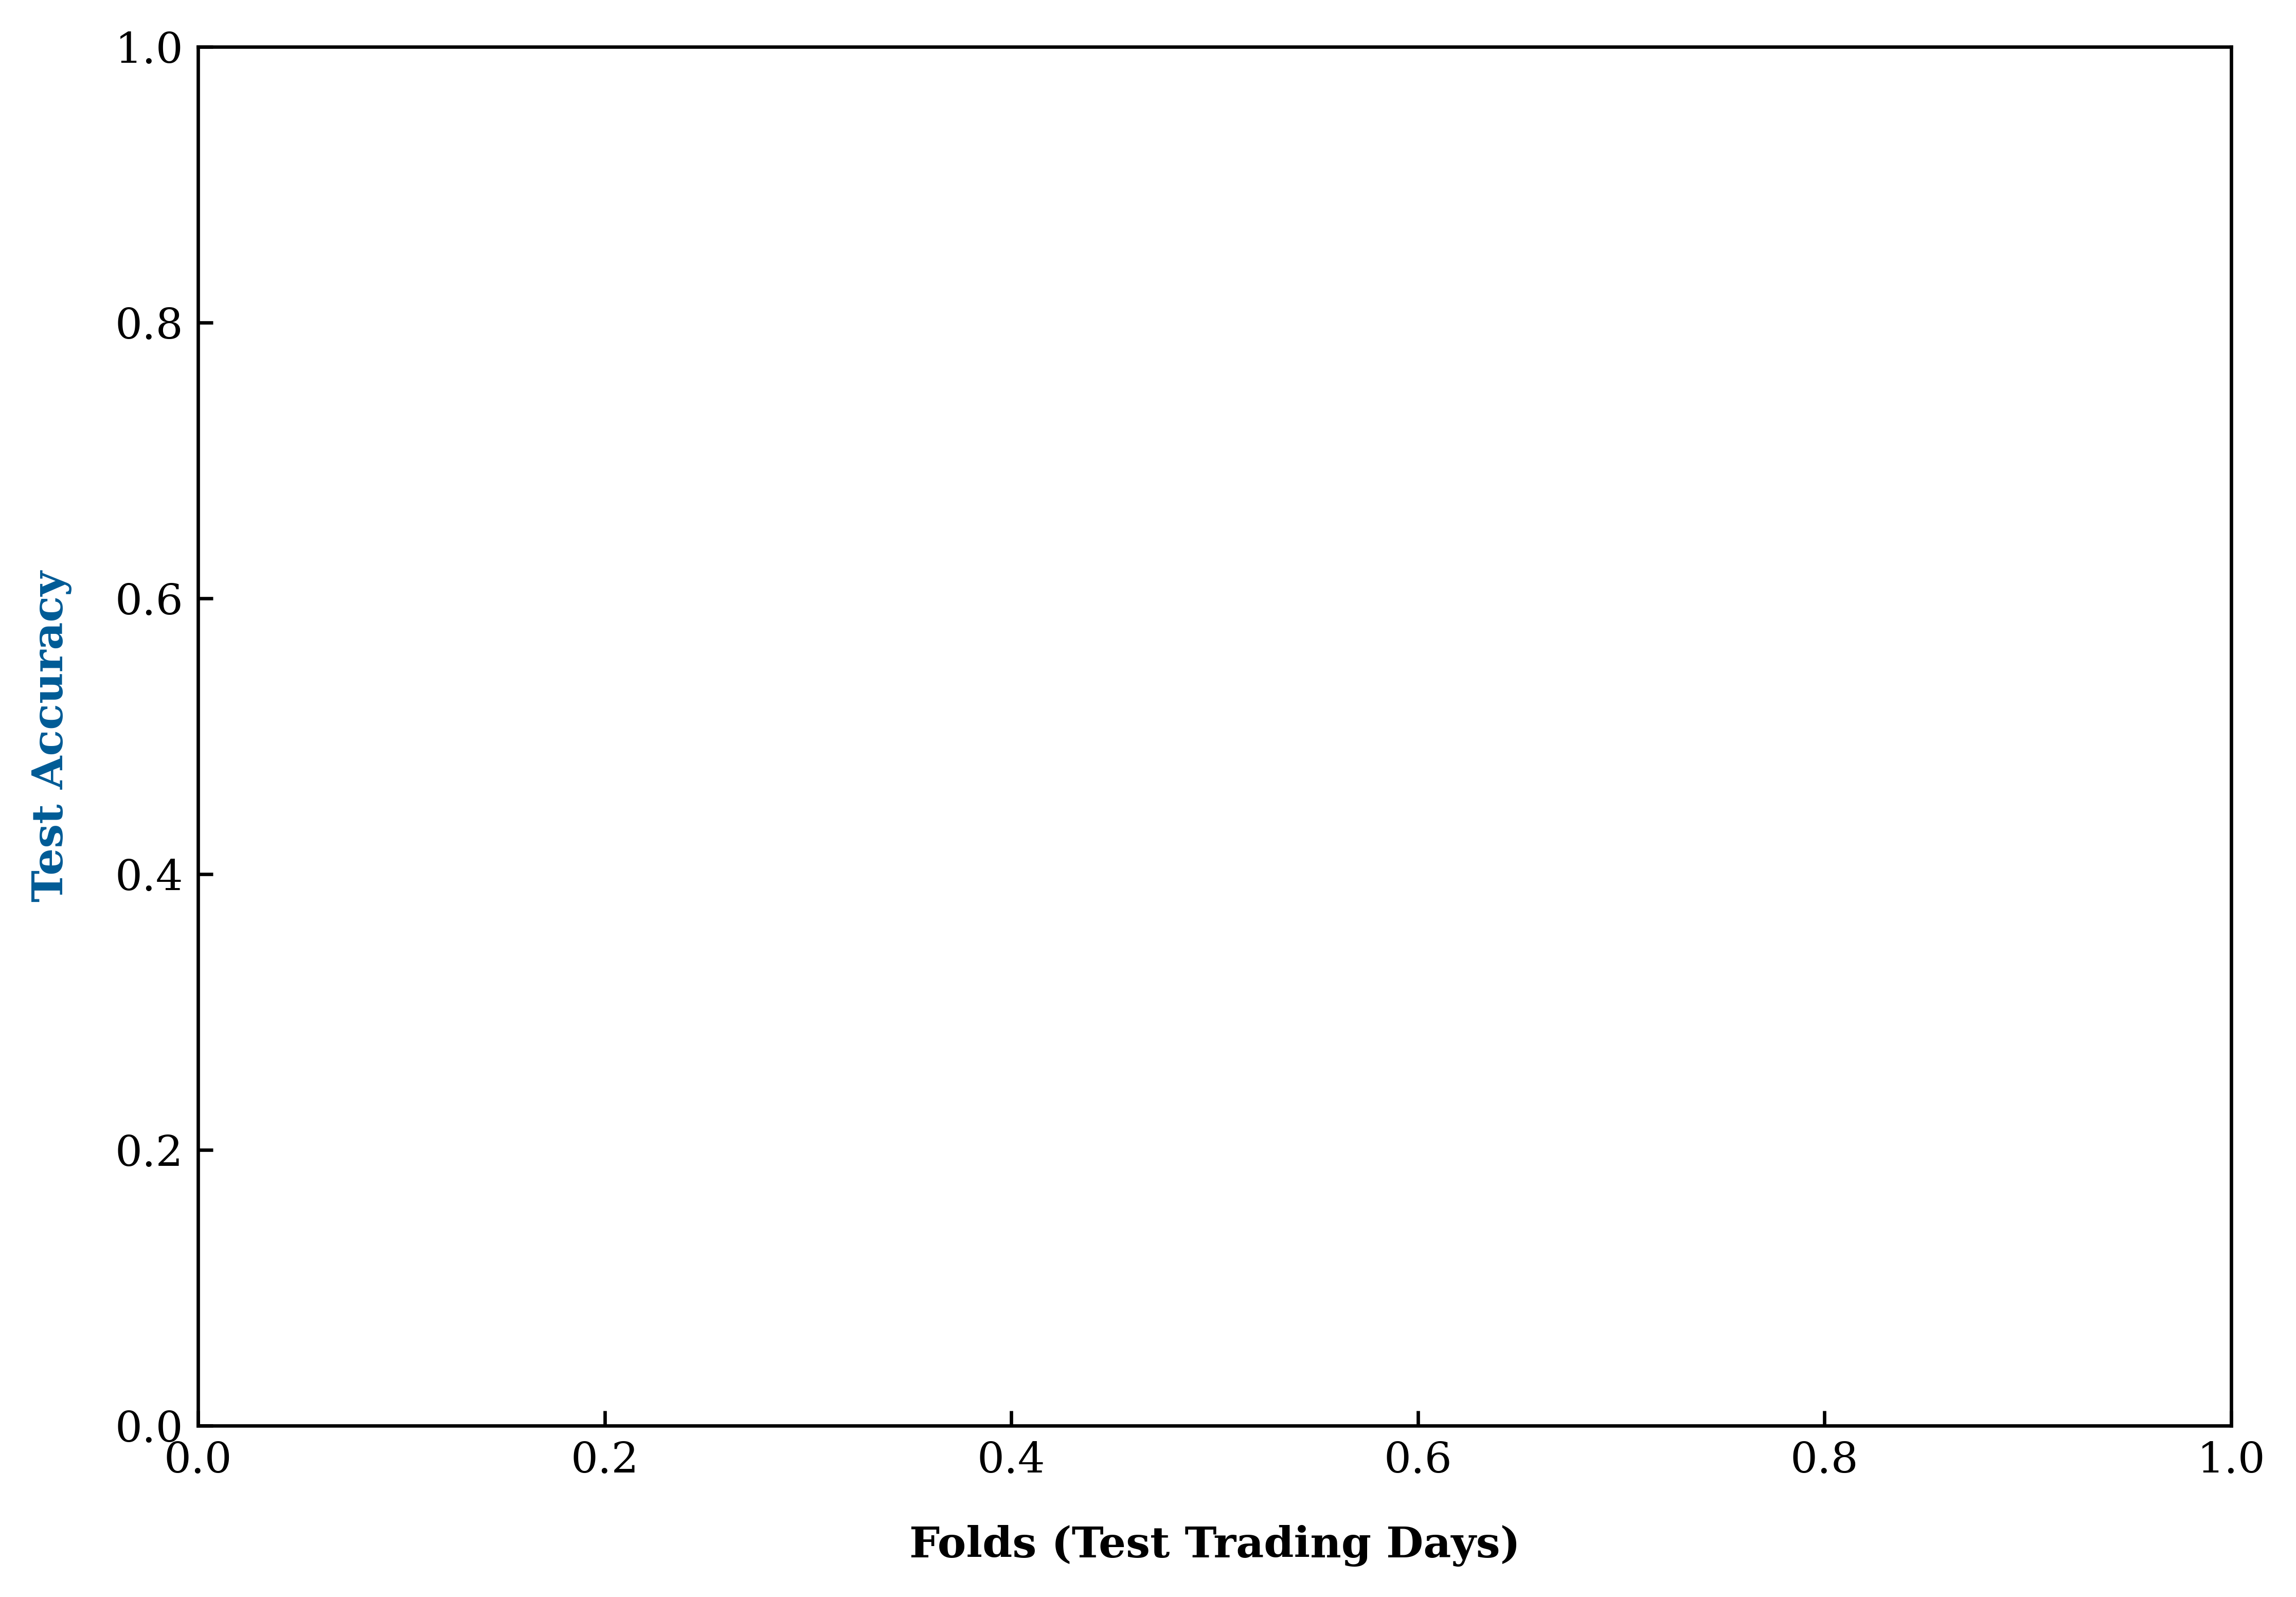

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

folds = np.arange(1, 9)
test_accuracy_ideal = np.array([item["accuracy"] for item in fold_summary_metrics_ideal])
l1_density_ideal = np.array([item["l1_sparsity"] for item in fold_summary_metrics_ideal])
l2_density_ideal = np.array([item["l2_sparsity"] for item in fold_summary_metrics_ideal])

# Globally force classic MATLAB inward ticks and formatting
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"]  = ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"]

# Adjusted figure size slightly to make clean room for the bottom legend
fig, ax1 = plt.subplots(figsize=(8.5, 5.8), dpi=600) 

# Configure Primary Axis (Left)
ax1.set_xlabel('Folds (Test Trading Days)', fontweight='bold', labelpad=10)
ax1.set_ylabel('Test Accuracy', color="#005b96", fontweight='bold', labelpad=10)
line1 = ax1.plot(folds, test_accuracy_ideal, color="#005b96", marker='o', linewidth=2.5, markersize=7, label='Test Accuracy')

# Dynamic vertical calculation for accuracy bounds
ymin = min(test_accuracy_ideal) - 0.03
ymax = max(test_accuracy_ideal) + 0.03
ax1.set_ylim(min(0.40, ymin), max(0.65, ymax)) 

ax1.tick_params(axis='y', labelcolor="#005b96", length=6)
ax1.tick_params(axis='x', length=6)
ax1.set_xticks(folds) 

# MATLAB-style grid layout
ax1.grid(True, linestyle=':', color='gray', alpha=0.5, linewidth=1.0)

# Configure Secondary Axis (Right)
ax2 = ax1.twinx()
ax2.set_ylabel('Spike Activation Density (%) [Log Scale]', color='black', fontweight='bold', labelpad=12)

line2 = ax2.plot(folds, l1_density_ideal, color="#d95f02", marker='s', linestyle='--', linewidth=2, markersize=7, label='Layer 1 (Hidden)')
line3 = ax2.plot(folds, l2_density_ideal, color="#1b9e77", marker='^', linestyle='-.', linewidth=2, markersize=7, label='Layer 2 (Output)')

# Apply log scale and handle ticks
ax2.set_yscale('log')

# --- FIX: Set data limits and manually override the LogLocator ticks ---
all_densities = np.concatenate([l1_density_ideal, l2_density_ideal])
ax2.set_ylim(min(all_densities) * 0.9, max(all_densities) * 1.1)

# Tell the log scale to show ticks inside the fractional range (e.g., 0.2, 0.3, 0.4, 0.6, 0.8)
ax2.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8)))

# Clean format string to guarantee they print cleanly on the right axis border
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax2.yaxis.set_minor_formatter(ticker.NullFormatter()) 

# Explicitly make sure right axis ticks point inside
ax2.tick_params(axis='y', which='both', labelcolor='black', length=6, direction='in')

# Fix the broken top bounding box line caused by twinx
ax1.set_zorder(ax2.get_zorder() + 1)  
ax1.set_frame_on(False)               
ax2.set_frame_on(True)                

# Unified Legend - Positioned safely OUTSIDE below the X-axis
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, 
           frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.8)

plt.title("Hardware performance under Ideal conditions", fontweight='bold', pad=15)

fig.tight_layout(pad=1.5)
plt.savefig("evaluation_plot_ideal.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [6]:
print(fold_summary_metrics_ideal)
print(l1_density_ideal)
print(l2_density_ideal)
print(l1_density_ideal.min(), l1_density_ideal.max())
print(l2_density_ideal.min(), l2_density_ideal.max())

NameError: name 'fold_summary_metrics_ideal' is not defined

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Sample arrays matching your code structure
folds = np.arange(1, 9)
accuracy = np.array([item["accuracy"] for item in fold_summary_metrics])
l1_density = np.array([item["l1_sparsity"] for item in fold_summary_metrics])
l2_density = np.array([item["l2_sparsity"] for item in fold_summary_metrics])

# Globally force classic MATLAB inward ticks and formatting
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"]  = ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"]

# Adjusted figure size slightly to make clean room for the bottom legend
fig, ax1 = plt.subplots(figsize=(8.5, 5.8), dpi=600) 

# Configure Primary Axis (Left)
ax1.set_xlabel('Folds (Test Trading Days)', fontweight='bold', labelpad=10)
ax1.set_ylabel('Test Accuracy', color="#005b96", fontweight='bold', labelpad=10)
line1 = ax1.plot(folds, accuracy, color="#005b96", marker='o', linewidth=2.5, markersize=7, label='Test Accuracy')

# --- FIX 1: Dynamic vertical bounds to prevent lines cutting through the top frame ---
ymin = min(accuracy) - 0.03
ymax = max(accuracy) + 0.03
ax1.set_ylim(min(0.40, ymin), max(0.65, ymax)) 

ax1.tick_params(axis='y', labelcolor="#005b96", length=6)
ax1.tick_params(axis='x', length=6)
ax1.set_xticks(folds) # Explicitly show every fold integer

# MATLAB-style grid layout
ax1.grid(True, linestyle=':', color='gray', alpha=0.5, linewidth=1.0)

# Configure Secondary Axis (Right)
ax2 = ax1.twinx()
ax2.set_ylabel('Spike Activation Density (%) [Log Scale]', color='black', fontweight='bold', labelpad=12)

line2 = ax2.plot(folds, l1_density, color="#d95f02", marker='s', linestyle='--', linewidth=2, markersize=7, label='Layer 1 (Hidden)')
line3 = ax2.plot(folds, l2_density, color="#1b9e77", marker='^', linestyle='-.', linewidth=2, markersize=7, label='Layer 2 (Output)')

# Apply log scale
ax2.set_yscale('log')

# --- FIX 2: Set precise data limits and force log sub-interval ticks to display values ---
all_densities = np.concatenate([l1_density, l2_density])
ax2.set_ylim(min(all_densities) * 0.9, max(all_densities) * 1.1)

# Places ticks at fractional intervals within a single decade to guarantee visibility
ax2.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8)))

# Clean MATLAB scalar format (e.g., 0.25 instead of 2.5 x 10^-1)
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax2.yaxis.set_minor_formatter(ticker.NullFormatter()) 

# Apply tick styling to major and minor ticks on the right axis border
ax2.tick_params(axis='y', which='both', labelcolor='black', length=6, direction='in')

# Fix the broken top bounding box line caused by twinx
ax1.set_zorder(ax2.get_zorder() + 1)  
ax1.set_frame_on(False)               
ax2.set_frame_on(True)                

# Unified Legend - Positioned safely OUTSIDE below the X-axis
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]

# bbox_to_anchor points to (X, Y) coordinates relative to axes. (0.5, -0.18) drops it right below the center point.
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, 
           frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.8)

# Title for the SAF dataset
plt.title("Hardware performance under ≈ 3% SAF", fontweight='bold', pad=15)

# Use tight_layout with specified padding to ensure everything fits inside the PDF boundary
fig.tight_layout(pad=1.5)

# bbox_inches='tight' is critical here to ensure the outside legend isn't cropped during export
plt.savefig("evaluation_plot.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [ ]:
print(fold_summary_metrics[-1])

In [8]:
# LSTM architecture to get hte metrics needed to benchmark against our MSNN
class LSTM_net(nn.Module): 
    def __init__(self, input_size=288, hidden_size=128, num_classes=3):
        super(LSTM_net, self).__init__()
        
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True) 
        self.drop = nn.Dropout(.3)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        
        final_step_out = out[:, -1, :]
        final_step_out = self.drop(final_step_out)
        logits = self.fc(final_step_out)
        
        return logits
    
print(f"starting LSTM training on {device}")
torch.manual_seed(123)
lstm_fold_summary = []

lstm_net = LSTM_net(input_size=288, hidden_size=128, num_classes=3).to(device)

for fold_idx in range(8):
    print("*"*50 +  f"\n LSTM fold n° {fold_idx + 1}")
    
    train_loader, test_loader, fold_train_dataset = get_anchored_fold_loaders(
        fold_idx=fold_idx, 
        train_files=train_files, 
        test_files=test_files, 
        batch_size=256
    )
    
    if isinstance(fold_train_dataset, torch.utils.data.ConcatDataset):
        active_labels = torch.cat([ds.Y for ds in fold_train_dataset.datasets])
    else:
        active_labels = fold_train_dataset.Y
        
    if isinstance(fold_train_dataset, torch.utils.data.ConcatDataset):
        active_labels = torch.cat([ds.Y for ds in fold_train_dataset.datasets])
    else:
        active_labels = fold_train_dataset.Y
        
    w = weights(device=device, labels=active_labels)
    loss_fn = FocalLoss(alpha=w, gamma=2)
    
    num_epochs_per_fold = 10  
    optimizer = torch.optim.Adam(lstm_net.parameters(), lr=3e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs_per_fold, eta_min=1e-6)
    
    best_fold_acc = 0.0
    patience_counter = 0
    patience = 4
    
    for epoch in range(num_epochs_per_fold):
        lstm_net.train()
        epoch_loss = 0.0
        
        for batch_idx, (data, targets) in enumerate(train_loader):
            data = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).long()
            
            optimizer.zero_grad(set_to_none=True)
            logits = lstm_net(data)
            loss_val = loss_fn(logits, targets)
            
            loss_val.backward()
            torch.nn.utils.clip_grad_norm_(lstm_net.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss_val.item()
            
        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        
        # Evaluate 
        lstm_net.eval()
        with torch.no_grad():
            val_correct = 0
            val_total = 0
            for val_data, val_targets in test_loader:
                val_data = val_data.to(device, non_blocking=True)
                val_targets = val_targets.to(device, non_blocking=True).long()
                val_preds = lstm_net(val_data).argmax(dim=1)
                val_correct += (val_preds == val_targets).sum().item()
                val_total += val_targets.size(0)
            current_val_acc = val_correct / max(1, val_total)
            
        print(f"Fold {fold_idx+1} | Epoch [{epoch+1}/{num_epochs_per_fold}] | Loss: {avg_loss:.4f} | LSTM Test Acc: {current_val_acc*100:.2f}%")
        
        if current_val_acc > best_fold_acc:
            best_fold_acc = current_val_acc
            patience_counter = 0
            torch.save(lstm_net.state_dict(), f'best_lstm_fold_{fold_idx+1}.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("↳ Early stopping LSTM fold fine-tuning.")
                break

    print(f"\n--- Saving LSTM Metrics for Fold {fold_idx + 1} ---")
    lstm_fold_summary.append({
        "fold": fold_idx + 1,
        "accuracy": best_fold_acc
    })

# ---------------------------------------------------------
# 3. Final LSTM vs MSNN Summary Report
# ---------------------------------------------------------
print("\n" + "="*50)
print("FINAL LSTM BASELINE REPORT")
print("="*50)
print(f"{'Fold':<6} | {'LSTM Test Accuracy':<20}")
print("-"*50)
lstm_total_acc = 0
for entry in lstm_fold_summary:
    print(f"{entry['fold']:<6} | {entry['accuracy']*100:<19.2f}%")
    lstm_total_acc += entry['accuracy']

print("="*50)
print(f"LSTM 8-Fold Average Accuracy: {(lstm_total_acc / 8)*100:.2f}%")
    

starting LSTM training on cuda
**************************************************
 LSTM fold n° 1

***  fold == 1 ***
training files are up to: Train_Dst_NoAuction_MinMax_CF_1.txt
testing file: Test_Dst_NoAuction_MinMax_CF_2.txt
tensor([0.9808, 0.6656, 1.0776])


KeyboardInterrupt: 

In [9]:
import os, json

def run_lstm_experiment(seed, train_files, test_files, num_folds=8, num_epochs_per_fold=10, patience=4,
                         checkpoint_dir='/kaggle/working/LSTM/sweep'):
    """
    Runs the full anchored-fold LSTM training+eval pipeline once, for one seed.
    Returns a list of per-fold {"fold": i, "accuracy": acc} dicts.
    """
    os.makedirs(checkpoint_dir, exist_ok=True)
    torch.manual_seed(seed)

    lstm_net = LSTM_net(input_size=288, hidden_size=128, num_classes=3).to(device)
    fold_summary = []

    for fold_idx in range(num_folds):
        print(f"\n***** LSTM seed {seed} — fold {fold_idx + 1} *****")

        train_loader, test_loader, fold_train_dataset = get_anchored_fold_loaders(
            fold_idx=fold_idx, train_files=train_files, test_files=test_files, batch_size=256
        )

        if isinstance(fold_train_dataset, torch.utils.data.ConcatDataset):
            active_labels = torch.cat([ds.Y for ds in fold_train_dataset.datasets])
        else:
            active_labels = fold_train_dataset.Y

        w = weights(device=device, labels=active_labels)
        loss_fn = FocalLoss(alpha=w, gamma=2)

        optimizer = torch.optim.Adam(lstm_net.parameters(), lr=3e-4, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs_per_fold, eta_min=1e-6)

        best_fold_acc = 0.0
        patience_counter = 0
        ckpt_path = f'{checkpoint_dir}/lstm_seed{seed}_fold{fold_idx+1}.pt'

        for epoch in range(num_epochs_per_fold):
            lstm_net.train()
            epoch_loss = 0.0
            for data, targets in train_loader:
                data = data.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True).long()

                optimizer.zero_grad(set_to_none=True)
                loss_val = loss_fn(lstm_net(data), targets)
                loss_val.backward()
                torch.nn.utils.clip_grad_norm_(lstm_net.parameters(), max_norm=1.0)
                optimizer.step()
                epoch_loss += loss_val.item()
            scheduler.step()

            lstm_net.eval()
            with torch.no_grad():
                correct, total = 0, 0
                for val_data, val_targets in test_loader:
                    val_data = val_data.to(device, non_blocking=True)
                    val_targets = val_targets.to(device, non_blocking=True).long()
                    preds = lstm_net(val_data).argmax(dim=1)
                    correct += (preds == val_targets).sum().item()
                    total += val_targets.size(0)
                current_val_acc = correct / max(1, total)

            print(f"Fold {fold_idx+1} | Epoch [{epoch+1}/{num_epochs_per_fold}] | "
                  f"Loss: {epoch_loss/len(train_loader):.4f} | LSTM Test Acc: {current_val_acc*100:.2f}%")

            if current_val_acc > best_fold_acc:
                best_fold_acc = current_val_acc
                patience_counter = 0
                torch.save(lstm_net.state_dict(), ckpt_path)
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print("↳ Early stopping LSTM fold fine-tuning.")
                    break

        fold_summary.append({"fold": fold_idx + 1, "accuracy": best_fold_acc})

    return fold_summary


def run_lstm_seed_if_needed(seed, train_files, test_files, results_dir='/kaggle/working/LSTM/results'):
    """Resume-safe wrapper — skips a seed if its result was already saved."""
    os.makedirs(results_dir, exist_ok=True)
    result_path = os.path.join(results_dir, f"lstm_seed{seed}.json")

    if os.path.exists(result_path):
        print(f"Skipping LSTM seed {seed} — already completed.")
        with open(result_path) as f:
            return json.load(f)

    result = run_lstm_experiment(seed, train_files, test_files)

    with open(result_path, 'w') as f:
        json.dump(result, f)

    return result


# --- Run the sweep, same seed set as your MSNN runs ---
lstm_seeds = [123, 42, 7]
all_lstm_runs = []
for s in lstm_seeds:
    all_lstm_runs.append(run_lstm_seed_if_needed(s, train_files, test_files))


# --- Aggregate ---
import numpy as np

def aggregate_lstm(all_runs, num_folds=8):
    acc_matrix = np.array([[run[f]["accuracy"] for f in range(num_folds)] for run in all_runs])
    return acc_matrix.mean(axis=0), acc_matrix.std(axis=0)

lstm_mean, lstm_std = aggregate_lstm(all_lstm_runs)
print("LSTM accuracy (mean ± std) per fold:", lstm_mean, "±", lstm_std)
print(f"LSTM 8-fold average accuracy: {lstm_mean.mean()*100:.2f}%")


***** LSTM seed 123 — fold 1 *****

***  fold == 1 ***
training files are up to: Train_Dst_NoAuction_MinMax_CF_1.txt
testing file: Test_Dst_NoAuction_MinMax_CF_2.txt
tensor([0.9808, 0.6656, 1.0776])
Fold 1 | Epoch [1/10] | Loss: 0.3602 | LSTM Test Acc: 29.28%
Fold 1 | Epoch [2/10] | Loss: 0.3394 | LSTM Test Acc: 41.41%
Fold 1 | Epoch [3/10] | Loss: 0.3238 | LSTM Test Acc: 58.08%
Fold 1 | Epoch [4/10] | Loss: 0.3070 | LSTM Test Acc: 61.31%
Fold 1 | Epoch [5/10] | Loss: 0.2915 | LSTM Test Acc: 61.15%
Fold 1 | Epoch [6/10] | Loss: 0.2788 | LSTM Test Acc: 60.92%
Fold 1 | Epoch [7/10] | Loss: 0.2699 | LSTM Test Acc: 60.57%
Fold 1 | Epoch [8/10] | Loss: 0.2651 | LSTM Test Acc: 60.38%
↳ Early stopping LSTM fold fine-tuning.

***** LSTM seed 123 — fold 2 *****

***  fold == 2 ***
training files are up to: Train_Dst_NoAuction_MinMax_CF_2.txt
testing file: Test_Dst_NoAuction_MinMax_CF_3.txt
tensor([0.9635, 0.6915, 1.0353])
Fold 2 | Epoch [1/10] | Loss: 0.2623 | LSTM Test Acc: 60.59%
Fold 2 | Ep

In [ ]:
def calculate_hardware_metrics(input_density=0.02, l1_density=0.0188, l2_density=0.0055, log=True):
    inputs = 288
    hidden = 128
    outputs = 3
    timesteps = 30

    # --- Corrected Hardware Parameters ---
    bits_per_device = 4
    devices_per_weight = 2  
    
    # Adjusted upward to account for parasitic line capacitance (RC delay)
    energy_per_synop_pj = 1.0       
    
    # Adjusted to reflect full column readout overhead (not just an isolated SAR step)
    adc_energy_pj_per_read = 8.0    
    
    # Added: Energy consumed by LIF neuron membrane integration per timestep
    energy_per_neuron_step_pj = 2.5 
    
    # Adjusted upward to reflect real peripheral control circuits + distribution networks
    static_power_uw = 75.0            
    latency_per_step_ns = 100

    # Topology and memory
    params_l1 = inputs * hidden
    params_l2 = hidden * outputs
    total_params = params_l1 + params_l2
    total_devices = total_params * devices_per_weight
    memory_footprint_kb = (total_devices * bits_per_device) / (8 * 1024)

    # Spike and SynOp math
    total_input_spikes = inputs * timesteps * input_density
    total_hidden_spikes = hidden * timesteps * l1_density
    synops_l1 = total_input_spikes * hidden
    synops_l2 = total_hidden_spikes * outputs
    total_synops = synops_l1 + synops_l2

    # --- Energy Components (Calculated in nJ) ---
    synop_energy_nj = (total_synops * energy_per_synop_pj) / 1000  
    
    total_adc_reads = (hidden + outputs) * timesteps
    adc_energy_nj = (total_adc_reads * adc_energy_pj_per_read) / 1000  

    # Added: Neuron integration energy component
    total_neuron_updates = (hidden + outputs) * timesteps
    neuron_energy_nj = (total_neuron_updates * energy_per_neuron_step_pj) / 1000

    latency_us = (timesteps * latency_per_step_ns) / 1000
    static_energy_nj = (static_power_uw * latency_us) / 1000  

    # Updated system energy sum
    total_energy_nj = synop_energy_nj + adc_energy_nj + neuron_energy_nj + static_energy_nj

    # ... keeping your logging format below ...

    metrics = []
    if log:
        print("*"*50)
        print("hardware metrics:")
        print("*"*50)
        print(f"Number of parameters:       {total_params:,}")
        print(f"Number of RRAM Devices:     {total_devices:,} (Differential)")
        print(f"Memory Footprint:           {memory_footprint_kb:.2f} KB")
        print("+" * 50)
        print(f"Average L1 Firing Rate:     {l1_density * 100:.2f}%")
        print(f"Average L2 Firing Rate:     {l2_density * 100:.2f}%")
        print(f"Total Input Spikes:         {int(total_input_spikes):,}")
        print(f"Total Hidden Spikes:        {int(total_hidden_spikes):,}")
        print("+" * 50)
        print(f"Total SynOps:               {int(total_synops):,}")
        print(f"  -> Device-level SynOp Energy:  {synop_energy_nj:.4f} nJ  (analog crossbar switching only)")
        print(f"  -> ADC Conversion Energy:      {adc_energy_nj:.4f} nJ  ({total_adc_reads} reads @ {adc_energy_pj_per_read} pJ/read)")
        print(f"  -> Static/Leakage Energy:      {static_energy_nj:.4f} nJ  (@ {static_power_uw} µW over {latency_us:.2f} µs)")
        print(f"  -> TOTAL System-Level Energy:  {total_energy_nj:.4f} nJ")
        print(f"Inference Latency:          {latency_us:.2f} µs")
        print("+"*50)
        print("NOTE: Device-level SynOp energy alone is NOT directly comparable to full-chip")
        print("      measurements (e.g. Wu et al. 2021, 10.3 µJ/sample) which include ADC,")
        print("      periphery, and static power over a much longer real sample duration.")
        print("+"*50)

    metrics.append({
        "num_param": total_params,
        "num_rram": total_devices,
        "memory": memory_footprint_kb,
        "total_hidden_spikes": int(total_hidden_spikes),
        "total_input_spikes": int(total_input_spikes),
        "total_synops": int(total_synops),
        "synop_energy_nj": synop_energy_nj,
        "adc_energy_nj": adc_energy_nj,
        "static_energy_nj": static_energy_nj,
        "total_energy_nj": total_energy_nj,
        "inference_latency": latency_us,
    })

    return metrics

avg_l1_density = np.mean([item["l1_sparsity"] for item in fold_summary_metrics])
avg_l2_density = np.mean([item["l2_sparsity"] for item in fold_summary_metrics])
avg_input_density = np.mean([item["input_sparsity"] for item in fold_summary_metrics])

ms = calculate_hardware_metrics(input_density=avg_input_density, l1_density=avg_l1_density, l2_density=avg_l2_density)
print(avg_input_density)

In [ ]:
# ======================================================================
# Digital LSTM vs. MSNN Hardware & Area Comparison Calculator
# ======================================================================

def calculate_baseline_comparison():
    # --- 1. Architectural & Topography Constants ---
    inputs = 288
    hidden = 128
    outputs = 3
    timesteps = 30
    
    # MSNN values from your hardware profile
    msnn_devices = ms[0]["num_rram"]
    msnn_synops = ms[0]["total_synops"]
    msnn_energy_nj = ms[0]["total_energy_nj"]
    
    # --- 2. LSTM Calculations ---
    # LSTM has 4 gates: Input, Forget, Cell, Output
    # Parameters per gate = (Inputs * Hidden) + (Hidden * Hidden) + Hidden (bias)
    params_per_gate = (inputs * hidden) + (hidden * hidden) + hidden
    lstm_params_layer = 4 * params_per_gate
    lstm_params_output = (hidden * outputs) + outputs
    lstm_total_params = lstm_params_layer + lstm_params_output
    
    # Dense LSTMs perform MAC operations for every parameter at every timestep
    lstm_total_macs = lstm_total_params * timesteps
    
    # Energy constant for 32-bit floating-point digital MAC (Horowitz ISSCC standard: ~3.1 pJ per MAC)
    energy_per_mac_pj = 3.1
    lstm_energy_nj = (lstm_total_macs * energy_per_mac_pj) / 1000
    
    # --- 3. Area Estimation Constants (RRAM CIM vs. Digital CMOS) ---
    # Approximate layout area per RRAM device (assuming standard crossbar node, e.g., 65nm or 28nm roughly ~4-10 F^2)
    # Let's use a standard literature estimate: ~0.04 um^2 per RRAM cell including minimal peripheral CMOS footprint share
    # Or macro-level density estimation: ~1000 um^2 per Kb for dense RRAM crossbars.
    rram_area_per_device_um2 = 0.04 
    msnn_crossbar_area_um2 = msnn_devices * rram_area_per_device_um2
    
    # Digital Standard Cell Area estimation for LSTM (32-bit floating point MAC units and registers)
    # A standard 32-bit FP MAC cell in CMOS takes roughly 10,000 to 20,000 gates (~5000 um^2 at 65nm per equivalent gate block)
    # Alternatively, total area proportional to parameter storage and active datapath logic.
    # Let's provide a clear transistor/gate equivalent layout approximation.
    digital_gate_area_um2 = 1.5  # Typical 65nm 2-input NAND equivalent area
    # A 32-bit floating point multiplier/accumulator takes roughly 15,000 equivalent gates. 
    # For a dense sequential LSTM running parallel blocks, let's derive footprint via standard synthesized cell area:
    lstm_estimated_area_um2 = lstm_total_params * 32 * digital_gate_area_um2 * 0.5 # compressed footprint factor

    # --- 4. Print Comparison Table ---
    print("="*65)
    print(f"{'HARDWARE METRIC':<30} | {'MSNN (RRAM CIM)':<15} | {'Digital LSTM':<15}")
    print("="*65)
    print(f"{'Parameters':<30} | {37248:<15,} | {lstm_total_params:<15,}")
    print(f"{'Memory Elements / Devices':<30} | {msnn_devices:<15,} | {lstm_total_params * 32:<15,}")
    print(f"{'Operations (SynOps vs MACs)':<30} | {msnn_synops:<15,} | {lstm_total_macs:<15,}")
    print(f"{'Estimated Energy (nJ)':<30} | {msnn_energy_nj:<15.4f} | {lstm_energy_nj:<15.2f}")
    print(f"{'Approx. Silicon Area (um²)':<30} | {msnn_crossbar_area_um2:<15.2f} | {lstm_estimated_area_um2:<15.2f}")
    print("="*65)
    
    # Efficiency Multipliers
    energy_speedup = lstm_energy_nj / msnn_energy_nj
    op_reduction = lstm_total_macs / msnn_synops
    print(f"\n[SUMMARY] MSNN achieves a {op_reduction:.1f}x reduction in operations")
    print(f"[SUMMARY] MSNN achieves a {energy_speedup:.1f}x improvement in energy efficiency over the LSTM baseline.")

calculate_baseline_comparison()

In [ ]:
import torch
import glob
import numpy as np
# (Include your other original imports here)

# 1. PASTE YOUR CLASSES AND FUNCTIONS HERE
# Paste: STEQuantize, MemristorCrossbar, MSNN, LOBDayDataset
# Paste: get_anchored_fold_loaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. DEFINE YOUR DATA FILES (Update these paths for your new environment)
train_files = sorted(glob.glob(
    "/kaggle/input/datasets/firmwired/fi-2010/data/published/BenchmarkDatasets/BenchmarkDatasets/BenchmarkDatasets/NoAuction/NoAuction_MinMax/NoAuction_MinMax_Training/Train_Dst_NoAuction_MinMax_CF_*.txt"
))
test_files = sorted(glob.glob(
    "/kaggle/input/datasets/firmwired/fi-2010/data/published/BenchmarkDatasets/BenchmarkDatasets/BenchmarkDatasets/NoAuction/NoAuction_MinMax/NoAuction_MinMax_Testing/Test_Dst_NoAuction_MinMax_CF_*.txt"
))

for i in range(8):
    # 3. SELECT THE FOLD YOU WANT TO TEST
    fold_idx = i # fold_idx = 0 means Fold 1

    # 4. LOAD THE ANCHORED DATA FOR THIS SPECIFIC FOLD
    # We only need the test_loader for inference, so we can ignore the train returns
    _, test_loader, _ = get_anchored_fold_loaders(
        fold_idx=fold_idx, 
        train_files=train_files, 
        test_files=test_files, 
        batch_size=256
    )

    # 5. INSTANTIATE THE MODEL
    new = MSNN(
        num_inputs=288, 
        num_hidden=128, 
        num_outputs=3, 
        beta=0.9, 
        num_levels=16, 
        saf_rate=0.03, 
        noise_std=0.05,
        force_ideal=False,
        force_noise_eval=True
    ).to(device)

    # 6. LOAD THE CORRESPONDING WEIGHTS
    # Match the model number to the fold_idx (fold_idx 0 -> model_1.pt)
    checkpoint_path = f'/kaggle/working/MSNN/noisy/model_8.pt'
    new.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))

    new.eval()
    new.reset_spike_metrics()

    # 7. RUN INFERENCE
    correct = 0
    total = 0

    print(f"\nRunning inference on Fold {fold_idx + 1}...")
    with torch.no_grad():
        for data, targets in test_loader:
            data = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).long()
            
            logits = new(data)
            preds = logits.argmax(dim=1)
            
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    accuracy = correct / max(1, total)
    print(accuracy)
    print(f"Test Accuracy for Fold {fold_idx + 1}: {accuracy * 100:.2f}%")

    


In [11]:
def run_anchored_experiment(seed, force_ideal, force_noise_eval, train_files, test_files,
                             num_folds=8, num_epochs_per_fold=10, patience=4,
                             checkpoint_dir='/kaggle/working/MSNN/sweep'):
    """
    Runs the full anchored-fold training+eval pipeline once, for one seed and one
    hardware condition. Returns a list of per-fold metric dicts (same shape as
    your existing fold_summary_metrics).
    """
    os.makedirs(checkpoint_dir, exist_ok=True)
    torch.manual_seed(seed)

    net_seeds = MSNN(num_inputs=288,
               num_hidden=128,
               num_outputs=3,
               beta=0.9,
               num_levels=16,
               saf_rate=0.03,
               noise_std=0.05,
               force_ideal=force_ideal,
               force_noise_eval=force_noise_eval
               ).to(device)
    
    fold_summary = []

    for fold_idx in range(num_folds):
        train_loader, test_loader, fold_train_dataset = get_anchored_fold_loaders(
            fold_idx=fold_idx, 
            train_files=train_files,
            test_files=test_files,
            batch_size=256
        )

        if isinstance(fold_train_dataset, torch.utils.data.ConcatDataset):
            active_labels = torch.cat([ds.Y for ds in fold_train_dataset.datasets])
        else:
            active_labels = fold_train_dataset.Y

        w = weights(device=device, labels=active_labels)
        loss_fn = FocalLoss(alpha=w, gamma=2)

        optimizer = torch.optim.Adam(net_seeds.parameters(), lr=3e-4, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs_per_fold, eta_min=1e-6)

        best_fold_acc = 0.0
        patience_counter = 0
        ckpt_path = f'{checkpoint_dir}/seed{seed}_{"ideal" if force_ideal else "noisy"}_fold{fold_idx+1}.pt'

        for epoch in range(num_epochs_per_fold):
            net_seeds.train()
            
            for data, targets in train_loader:
                data = data.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True).long()
                
                optimizer.zero_grad(set_to_none=True)
                
                loss_val = loss_fn(net_seeds(data), targets)
                
                loss_val.backward()
                torch.nn.utils.clip_grad_norm_(net_seeds.parameters(), max_norm=1.0)
                optimizer.step()
            scheduler.step()

            net_seeds.eval()
            with torch.no_grad():
                correct, total = 0, 0
                for val_data, val_targets in test_loader:
                    val_data = val_data.to(device, non_blocking=True)
                    val_targets = val_targets.to(device, non_blocking=True).long()
                    preds = net_seeds(val_data).argmax(dim=1)
                    correct += (preds == val_targets).sum().item()
                    total += val_targets.size(0)
                current_val_acc = correct / max(1, total)

            if current_val_acc > best_fold_acc:
                best_fold_acc = current_val_acc
                patience_counter = 0
                torch.save(net_seeds.state_dict(), ckpt_path)
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    break

        net_seeds.load_state_dict(torch.load(ckpt_path, map_location=device))

        total_input_sparsity, num_batches = 0.0, 0
        with torch.no_grad():
            for val_data, _ in test_loader:
                total_input_sparsity += val_data.float().mean().item()
                num_batches += 1
        fold_input_sparsity = total_input_sparsity / num_batches

        fold_profile = compute_hardware_metrics(test_loader, net_seeds, device)
        fold_summary.append({
            "fold": fold_idx + 1,
            "accuracy": fold_profile["accuracy"],
            "l1_sparsity": fold_profile["l1_sparsity"],
            "l2_sparsity": fold_profile["l2_sparsity"],
            "input_sparsity": fold_input_sparsity
        })

    return fold_summary


# Run Sweeeep
seeds = [123, 42, 7]   
all_noisy_runs = []
all_ideal_runs = []

for s in seeds:
    print(f"\n++++++++ seed {s} — noisy++++++")
    all_noisy_runs.append(run_anchored_experiment(s, force_ideal=False, force_noise_eval=True,
                                                    train_files=train_files, test_files=test_files))
    print(f"\n++++++++ seed {s} — ideal++++++")
    all_ideal_runs.append(run_anchored_experiment(s, force_ideal=True, force_noise_eval=False,
                                                    train_files=train_files, test_files=test_files))


++++++++ seed 123 — noisy++++++

***  fold == 1 ***
training files are up to: Train_Dst_NoAuction_MinMax_CF_1.txt
testing file: Test_Dst_NoAuction_MinMax_CF_2.txt
tensor([0.9808, 0.6656, 1.0776])

*** extracted hardware metrics ***
accuracy: 41.92%
layer 1 firing density : 5.874% spikes/neuron/step
layer 2 firing density : 3.423% spikes/neuron/step
total spikes emitted per sequence window (30): 228.63

***  fold == 2 ***
training files are up to: Train_Dst_NoAuction_MinMax_CF_2.txt
testing file: Test_Dst_NoAuction_MinMax_CF_3.txt
tensor([0.9635, 0.6915, 1.0353])

*** extracted hardware metrics ***
accuracy: 46.72%
layer 1 firing density : 6.692% spikes/neuron/step
layer 2 firing density : 4.272% spikes/neuron/step
total spikes emitted per sequence window (30): 260.80

***  fold == 3 ***
training files are up to: Train_Dst_NoAuction_MinMax_CF_3.txt
testing file: Test_Dst_NoAuction_MinMax_CF_4.txt
tensor([0.9739, 0.6873, 1.0327])

*** extracted hardware metrics ***
accuracy: 48.60%
laye

In [72]:
def aggregate_across_seeds(all_runs, num_folds=8):
    """all_runs: list of fold_summary lists (one per seed). Returns per-fold mean/std."""
    acc_matrix = np.array([[run[f]["accuracy"] for f in range(num_folds)] for run in all_runs])
    l1_matrix = np.array([[run[f]["l1_sparsity"] for f in range(num_folds)] for run in all_runs])
    l2_matrix = np.array([[run[f]["l2_sparsity"] for f in range(num_folds)] for run in all_runs])
    return {
        "acc_mean": acc_matrix.mean(axis=0), "acc_std": acc_matrix.std(axis=0),
        "l1_mean": l1_matrix.mean(axis=0), "l1_std": l1_matrix.std(axis=0),
        "l2_mean": l2_matrix.mean(axis=0), "l2_std": l2_matrix.std(axis=0),
    }

noisy_agg = aggregate_across_seeds(all_noisy_runs)
ideal_agg = aggregate_across_seeds(all_ideal_runs)
print("Noisy accuracy (mean ± std) per fold:", noisy_agg["acc_mean"], "±", noisy_agg["acc_std"])
print("Ideal accuracy (mean ± std) per fold:", ideal_agg["acc_mean"], "±", ideal_agg["acc_std"])

Noisy accuracy (mean ± std) per fold: [0.43582997 0.46826148 0.48645279 0.54074547 0.52750982 0.61965735
 0.59619011 0.56121383] ± [0.01650595 0.00442006 0.01186877 0.00531782 0.00712416 0.00885089
 0.01941716 0.0114676 ]
Ideal accuracy (mean ± std) per fold: [0.47430275 0.49601297 0.5301875  0.58900958 0.57877814 0.67195672
 0.6546489  0.63940249] ± [0.00995455 0.00783967 0.00749414 0.00410673 0.01159083 0.0079149
 0.00405025 0.00693974]


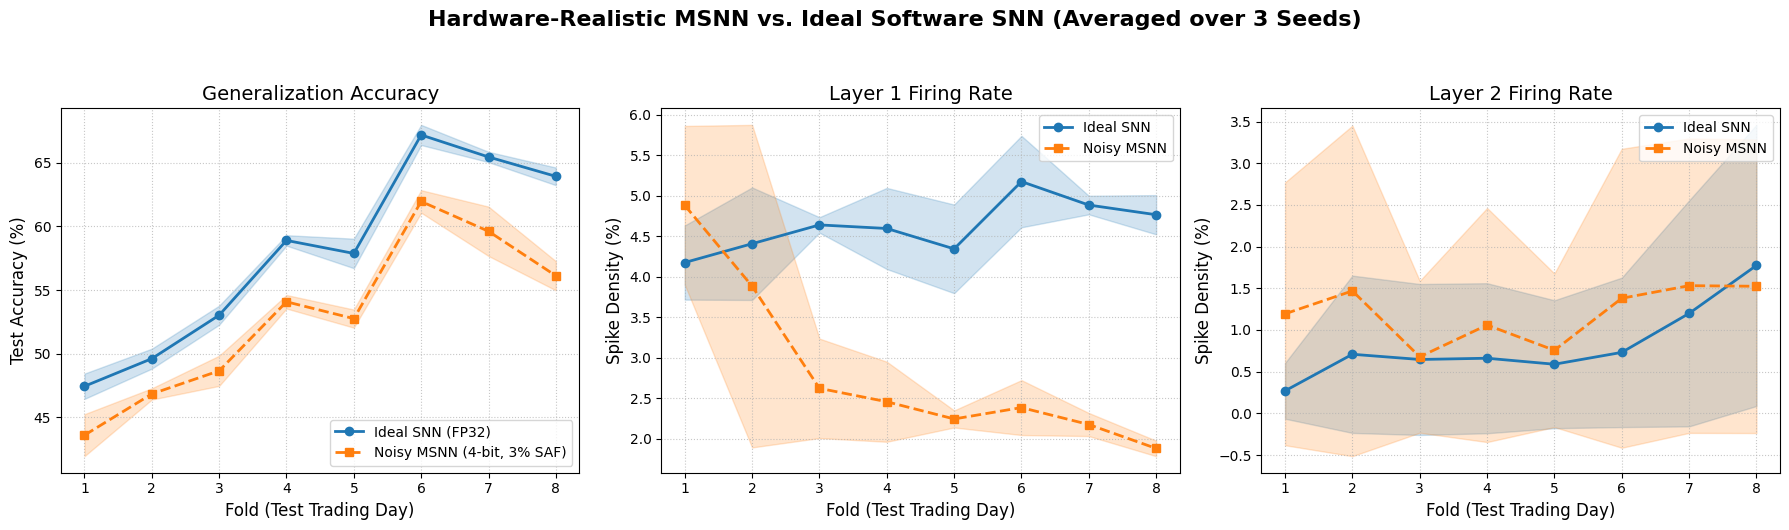

In [73]:
import matplotlib.pyplot as plt
import numpy as np

def plot_multiseed_results(noisy_agg, ideal_agg, num_folds=8):
    folds = np.arange(1, num_folds + 1)
    
    # Set up a 1x3 grid for the plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Hardware-Realistic MSNN vs. Ideal Software SNN (Averaged over 3 Seeds)", fontsize=16, fontweight='bold', y=1.05)

    # ==========================================
    # Plot 1: Test Accuracy
    # ==========================================
    # Ideal
    axes[0].plot(folds, ideal_agg["acc_mean"] * 100, label="Ideal SNN (FP32)", 
                 marker='o', linestyle='-', color='#1f77b4', linewidth=2)
    axes[0].fill_between(folds, 
                         (ideal_agg["acc_mean"] - ideal_agg["acc_std"]) * 100, 
                         (ideal_agg["acc_mean"] + ideal_agg["acc_std"]) * 100, 
                         color='#1f77b4', alpha=0.2)
    
    # Noisy
    axes[0].plot(folds, noisy_agg["acc_mean"] * 100, label="Noisy MSNN (4-bit, 3% SAF)", 
                 marker='s', linestyle='--', color='#ff7f0e', linewidth=2)
    axes[0].fill_between(folds, 
                         (noisy_agg["acc_mean"] - noisy_agg["acc_std"]) * 100, 
                         (noisy_agg["acc_mean"] + noisy_agg["acc_std"]) * 100, 
                         color='#ff7f0e', alpha=0.2)

    axes[0].set_title("Generalization Accuracy", fontsize=14)
    axes[0].set_xlabel("Fold (Test Trading Day)", fontsize=12)
    axes[0].set_ylabel("Test Accuracy (%)", fontsize=12)
    axes[0].legend(loc="lower right")
    axes[0].grid(True, linestyle=':', alpha=0.7)

    # ==========================================
    # Plot 2: Layer 1 Spike Density
    # ==========================================
    axes[1].plot(folds, ideal_agg["l1_mean"] * 100, label="Ideal SNN", 
                 marker='o', linestyle='-', color='#1f77b4', linewidth=2)
    axes[1].fill_between(folds, 
                         (ideal_agg["l1_mean"] - ideal_agg["l1_std"]) * 100, 
                         (ideal_agg["l1_mean"] + ideal_agg["l1_std"]) * 100, 
                         color='#1f77b4', alpha=0.2)
    
    axes[1].plot(folds, noisy_agg["l1_mean"] * 100, label="Noisy MSNN", 
                 marker='s', linestyle='--', color='#ff7f0e', linewidth=2)
    axes[1].fill_between(folds, 
                         (noisy_agg["l1_mean"] - noisy_agg["l1_std"]) * 100, 
                         (noisy_agg["l1_mean"] + noisy_agg["l1_std"]) * 100, 
                         color='#ff7f0e', alpha=0.2)

    axes[1].set_title("Layer 1 Firing Rate", fontsize=14)
    axes[1].set_xlabel("Fold (Test Trading Day)", fontsize=12)
    axes[1].set_ylabel("Spike Density (%)", fontsize=12)
    axes[1].legend(loc="upper right")
    axes[1].grid(True, linestyle=':', alpha=0.7)

    # ==========================================
    # Plot 3: Layer 2 Spike Density
    # ==========================================
    axes[2].plot(folds, ideal_agg["l2_mean"] * 100, label="Ideal SNN", 
                 marker='o', linestyle='-', color='#1f77b4', linewidth=2)
    axes[2].fill_between(folds, 
                         (ideal_agg["l2_mean"] - ideal_agg["l2_std"]) * 100, 
                         (ideal_agg["l2_mean"] + ideal_agg["l2_std"]) * 100, 
                         color='#1f77b4', alpha=0.2)
    
    axes[2].plot(folds, noisy_agg["l2_mean"] * 100, label="Noisy MSNN", 
                 marker='s', linestyle='--', color='#ff7f0e', linewidth=2)
    axes[2].fill_between(folds, 
                         (noisy_agg["l2_mean"] - noisy_agg["l2_std"]) * 100, 
                         (noisy_agg["l2_mean"] + noisy_agg["l2_std"]) * 100, 
                         color='#ff7f0e', alpha=0.2)

    axes[2].set_title("Layer 2 Firing Rate", fontsize=14)
    axes[2].set_xlabel("Fold (Test Trading Day)", fontsize=12)
    axes[2].set_ylabel("Spike Density (%)", fontsize=12)
    axes[2].legend(loc="upper right")
    axes[2].grid(True, linestyle=':', alpha=0.7)

    # Clean layout and render
    plt.tight_layout()
    plt.show()

# Run the plotting function using the dictionaries you just generated
plot_multiseed_results(noisy_agg, ideal_agg)

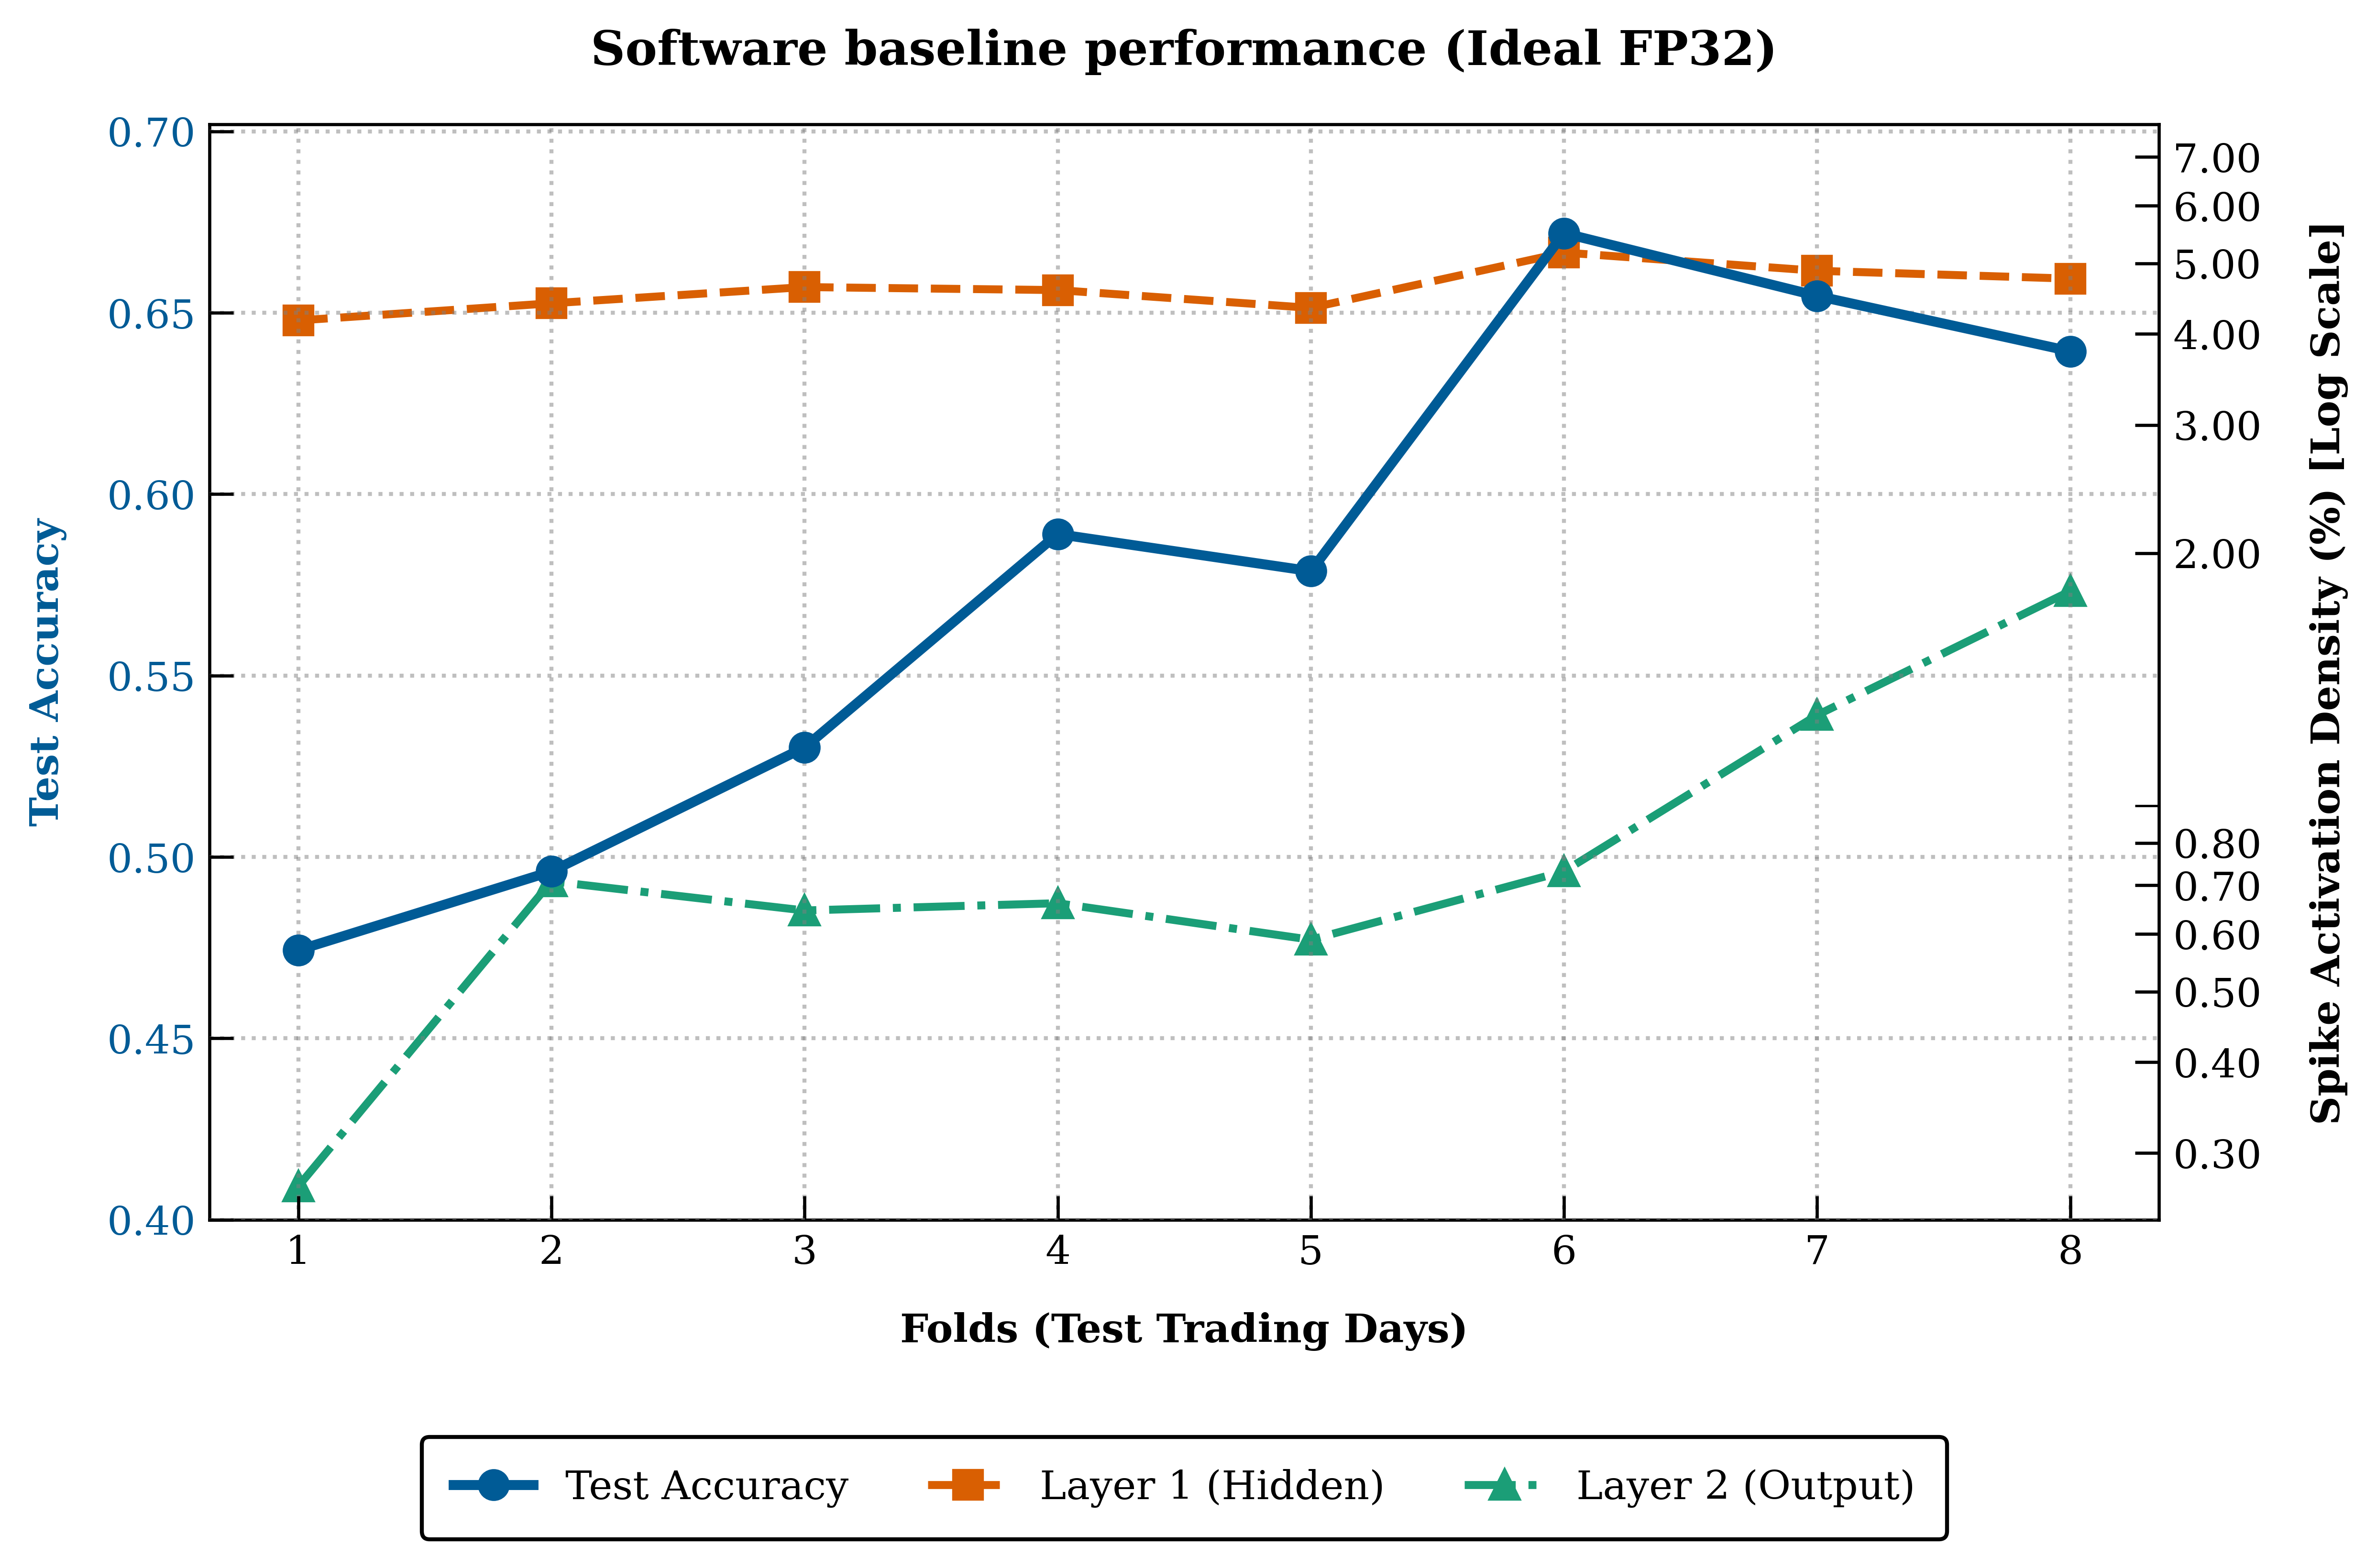

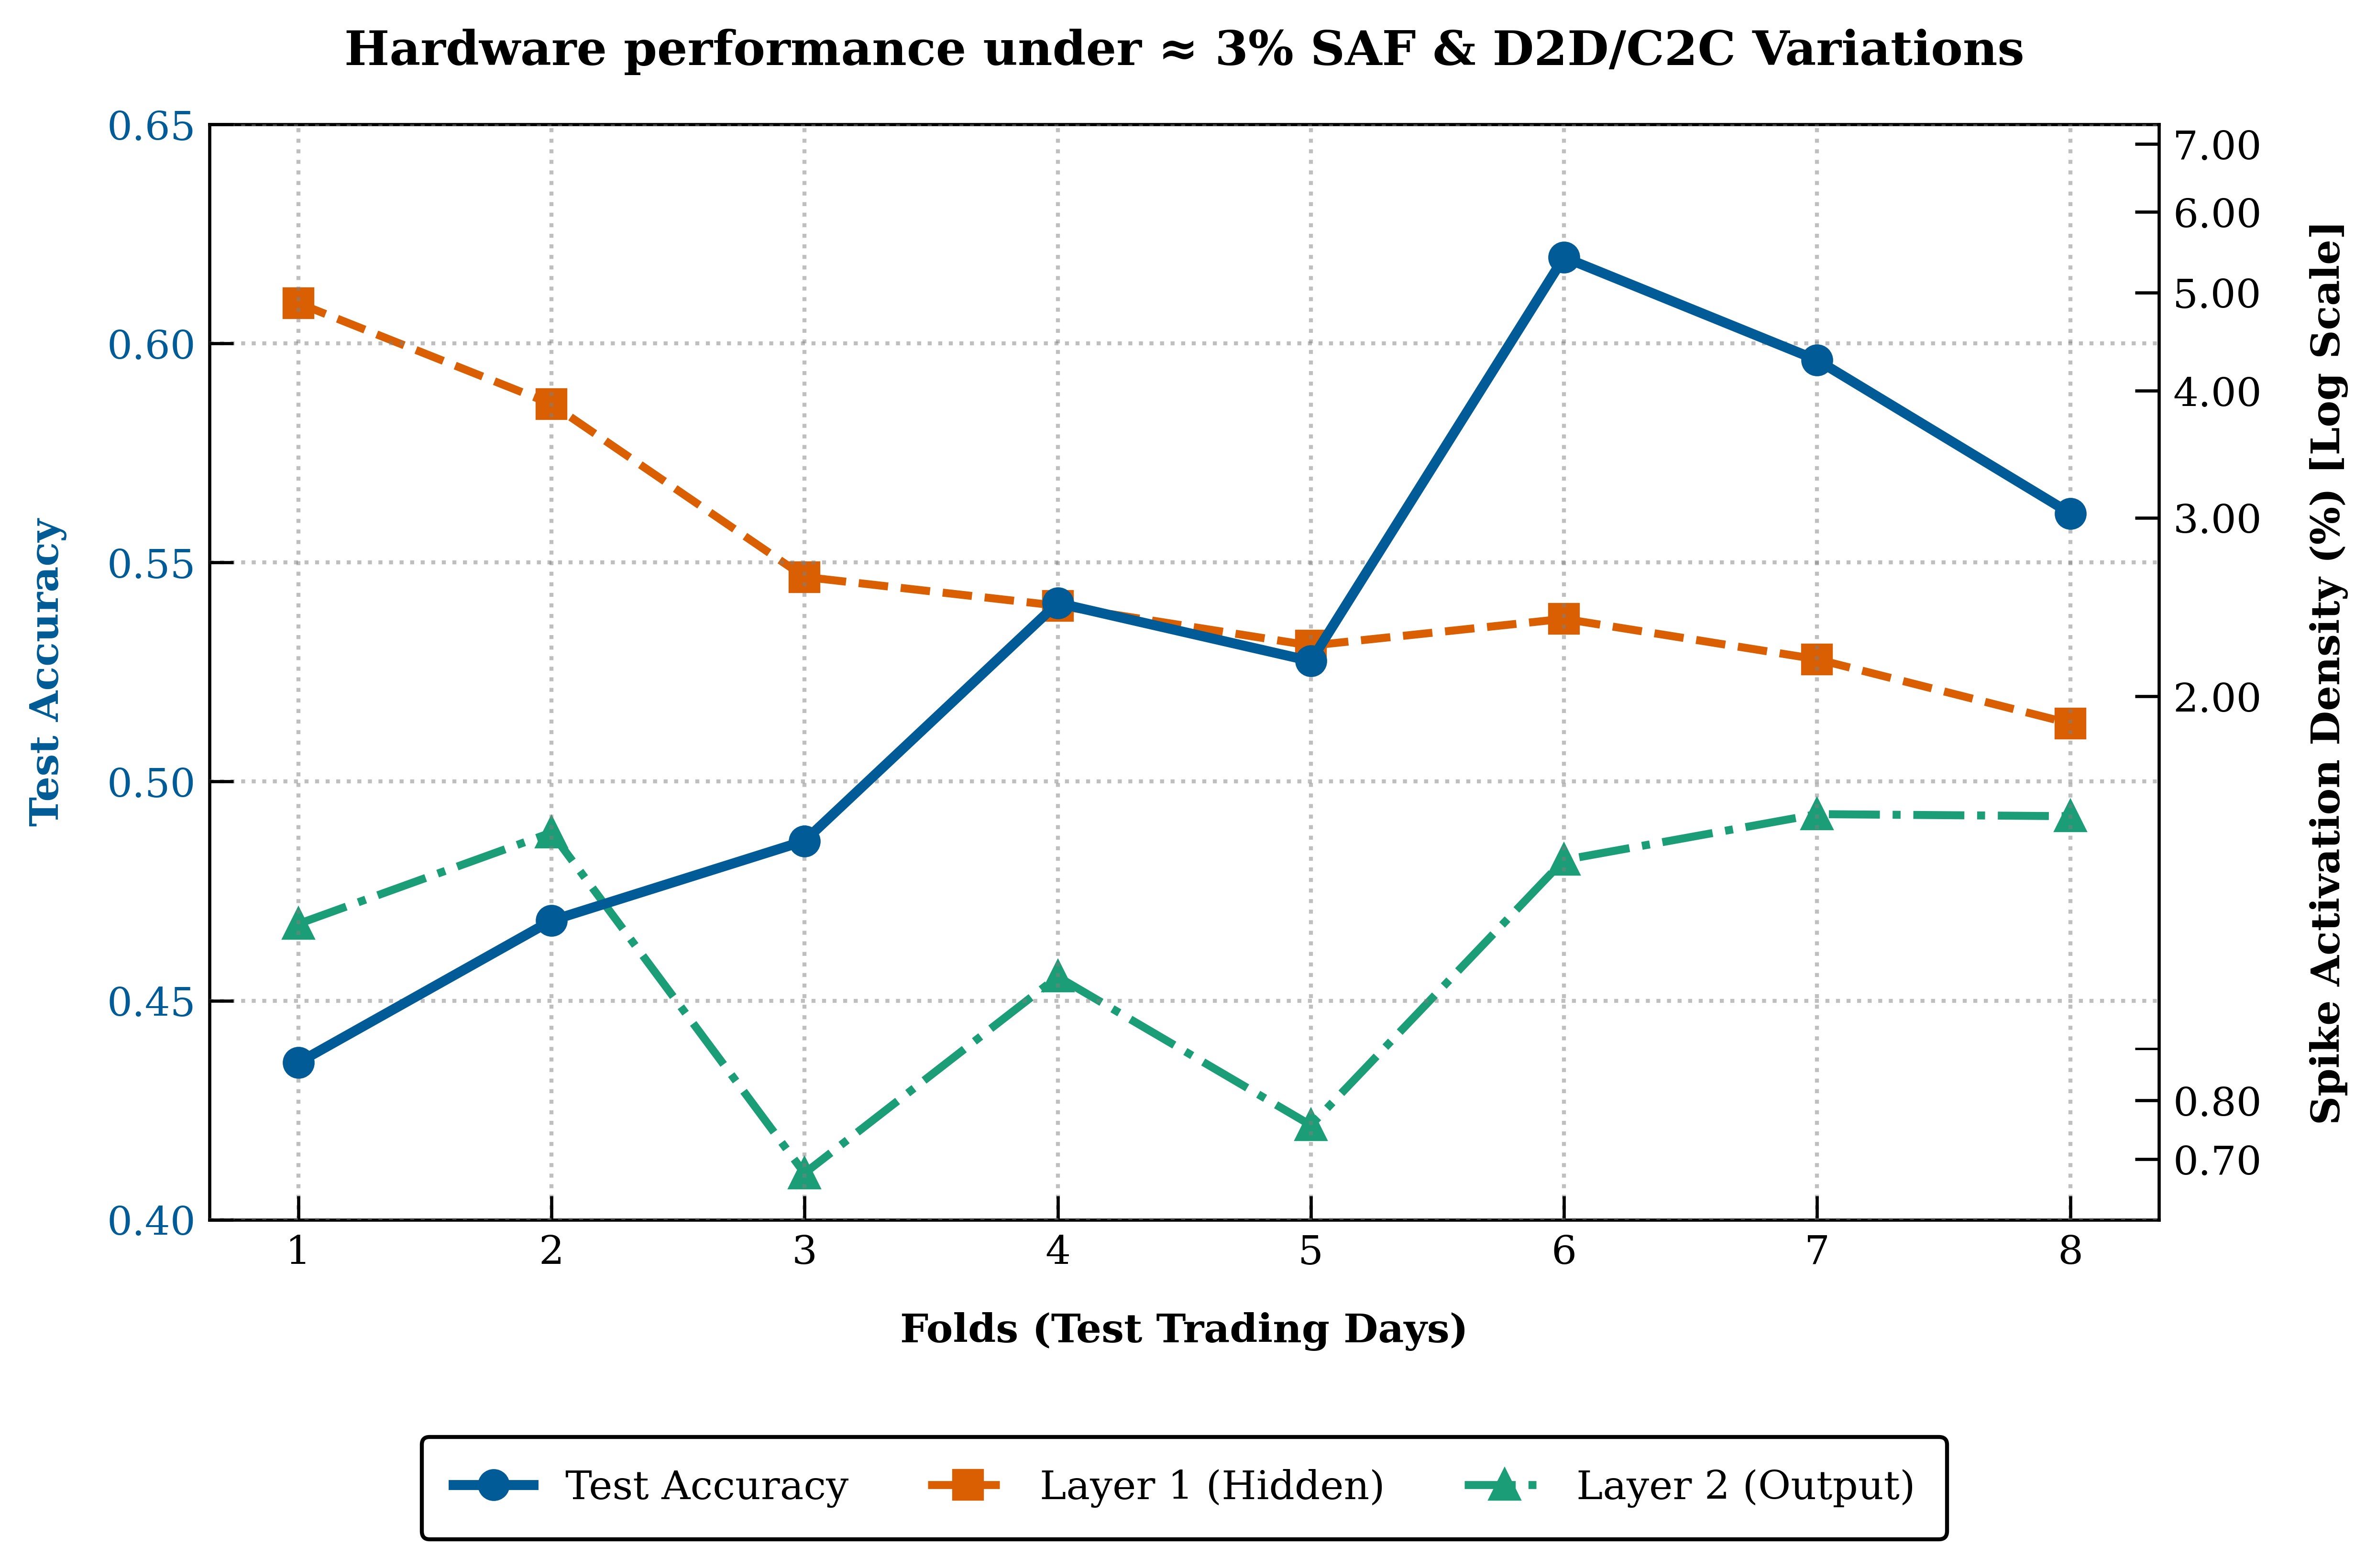

In [77]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Globally force classic MATLAB inward ticks and formatting
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"]  = ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"]

folds = np.arange(1, 9)

# =====================================================================
# PLOT 1: IDEAL HARDWARE
# =====================================================================
accuracy_ideal = ideal_agg["acc_mean"]
l1_density_ideal = ideal_agg["l1_mean"] * 100 
l2_density_ideal = ideal_agg["l2_mean"] * 100

fig1, ax1_ideal = plt.subplots(figsize=(8.5, 5.8), dpi=600) 

ax1_ideal.set_xlabel('Folds (Test Trading Days)', fontweight='bold', labelpad=10)
ax1_ideal.set_ylabel('Test Accuracy', color="#005b96", fontweight='bold', labelpad=10)
line1_ideal = ax1_ideal.plot(folds, accuracy_ideal, color="#005b96", marker='o', linewidth=2.5, markersize=7, label='Test Accuracy')

ymin_ideal = min(accuracy_ideal) - 0.03
ymax_ideal = max(accuracy_ideal) + 0.03
ax1_ideal.set_ylim(min(0.40, ymin_ideal), max(0.65, ymax_ideal)) 

ax1_ideal.tick_params(axis='y', labelcolor="#005b96", length=6)
ax1_ideal.tick_params(axis='x', length=6)
ax1_ideal.set_xticks(folds) 
ax1_ideal.grid(True, linestyle=':', color='gray', alpha=0.5, linewidth=1.0)

ax2_ideal = ax1_ideal.twinx()
ax2_ideal.set_ylabel('Spike Activation Density (%) [Log Scale]', color='black', fontweight='bold', labelpad=12)

line2_ideal = ax2_ideal.plot(folds, l1_density_ideal, color="#d95f02", marker='s', linestyle='--', linewidth=2, markersize=7, label='Layer 1 (Hidden)')
line3_ideal = ax2_ideal.plot(folds, l2_density_ideal, color="#1b9e77", marker='^', linestyle='-.', linewidth=2, markersize=7, label='Layer 2 (Output)')

ax2_ideal.set_yscale('log')
all_densities_ideal = np.concatenate([l1_density_ideal, l2_density_ideal])
ax2_ideal.set_ylim(min(all_densities_ideal) * 0.9, max(all_densities_ideal) * 1.5)
ax2_ideal.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8)))
ax2_ideal.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax2_ideal.yaxis.set_minor_formatter(ticker.NullFormatter()) 
ax2_ideal.tick_params(axis='y', which='both', labelcolor='black', length=6, direction='in')

ax1_ideal.set_zorder(ax2_ideal.get_zorder() + 1)  
ax1_ideal.set_frame_on(False)                
ax2_ideal.set_frame_on(True)                

lines_ideal = line1_ideal + line2_ideal + line3_ideal
labels_ideal = [l.get_label() for l in lines_ideal]
ax1_ideal.legend(lines_ideal, labels_ideal, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, 
                 frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.8)

plt.title("Software baseline performance (Ideal FP32)", fontweight='bold', pad=15)
fig1.tight_layout(pad=1.5)
plt.savefig("evaluation_plot_ideal.pdf", format='pdf', bbox_inches='tight')
plt.show()

# =====================================================================
# PLOT 2: NOISY HARDWARE
# =====================================================================
accuracy_noisy = noisy_agg["acc_mean"]
l1_density_noisy = noisy_agg["l1_mean"] * 100 
l2_density_noisy = noisy_agg["l2_mean"] * 100

fig2, ax1_noisy = plt.subplots(figsize=(8.5, 5.8), dpi=600) 

ax1_noisy.set_xlabel('Folds (Test Trading Days)', fontweight='bold', labelpad=10)
ax1_noisy.set_ylabel('Test Accuracy', color="#005b96", fontweight='bold', labelpad=10)
line1_noisy = ax1_noisy.plot(folds, accuracy_noisy, color="#005b96", marker='o', linewidth=2.5, markersize=7, label='Test Accuracy')

ymin_noisy = min(accuracy_noisy) - 0.03
ymax_noisy = max(accuracy_noisy) + 0.03
ax1_noisy.set_ylim(min(0.40, ymin_noisy), max(0.65, ymax_noisy)) 

ax1_noisy.tick_params(axis='y', labelcolor="#005b96", length=6)
ax1_noisy.tick_params(axis='x', length=6)
ax1_noisy.set_xticks(folds) 
ax1_noisy.grid(True, linestyle=':', color='gray', alpha=0.5, linewidth=1.0)

ax2_noisy = ax1_noisy.twinx()
ax2_noisy.set_ylabel('Spike Activation Density (%) [Log Scale]', color='black', fontweight='bold', labelpad=12)

line2_noisy = ax2_noisy.plot(folds, l1_density_noisy, color="#d95f02", marker='s', linestyle='--', linewidth=2, markersize=7, label='Layer 1 (Hidden)')
line3_noisy = ax2_noisy.plot(folds, l2_density_noisy, color="#1b9e77", marker='^', linestyle='-.', linewidth=2, markersize=7, label='Layer 2 (Output)')

ax2_noisy.set_yscale('log')
all_densities_noisy = np.concatenate([l1_density_noisy, l2_density_noisy])
ax2_noisy.set_ylim(min(all_densities_noisy) * 0.9, max(all_densities_noisy) * 1.5)
ax2_noisy.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8)))
ax2_noisy.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax2_noisy.yaxis.set_minor_formatter(ticker.NullFormatter()) 
ax2_noisy.tick_params(axis='y', which='both', labelcolor='black', length=6, direction='in')

ax1_noisy.set_zorder(ax2_noisy.get_zorder() + 1)  
ax1_noisy.set_frame_on(False)                  
ax2_noisy.set_frame_on(True)                

lines_noisy = line1_noisy + line2_noisy + line3_noisy
labels_noisy = [l.get_label() for l in lines_noisy] 
ax1_noisy.legend(lines_noisy, labels_noisy, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, 
                 frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, borderpad=0.8)

plt.title("Hardware performance under ≈ 3% SAF & D2D/C2C Variations", fontweight='bold', pad=15)
fig2.tight_layout(pad=1.5)
plt.savefig("evaluation_plot_noisy.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [90]:
import numpy as np
import matplotlib.pyplot as plt

folds = np.arange(1, 9)
noisy_mean = np.array([0.43582997, 0.46826148, 0.48645279, 0.54074547, 0.52750982, 0.61965735, 0.59619011, 0.56121383])
noisy_std  = np.array([0.01650595, 0.00442006, 0.01186877, 0.00531782, 0.00712416, 0.00885089, 0.01941716, 0.0114676])
ideal_mean = np.array([0.47430275, 0.49601297, 0.5301875, 0.58900958, 0.57877814, 0.67195672, 0.6546489, 0.63940249])
ideal_std  = np.array([0.00995455, 0.00783967, 0.00749414, 0.00410673, 0.01159083, 0.0079149, 0.00405025, 0.00693974])

setup_academic_style()
fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(folds, noisy_mean, color="#005b96", marker='o', linewidth=2.5, markersize=7, label='Noisy (Realistic Hardware)')
ax.fill_between(folds, noisy_mean - noisy_std, noisy_mean + noisy_std, color="#005b96", alpha=0.2)

ax.plot(folds, ideal_mean, color="#d95f02", marker='s', linewidth=2.5, markersize=7, label='Ideal (No Non-idealities)')
ax.fill_between(folds, ideal_mean - ideal_std, ideal_mean + ideal_std, color="#d95f02", alpha=0.2)

ax.set_xlabel('Folds (Test Trading Days)', fontweight='bold', labelpad=10)
ax.set_ylabel('Test Accuracy', fontweight='bold', labelpad=10)
ax.set_xticks(folds)
ax.grid(True, linestyle=':', color='gray', alpha=0.5, linewidth=1.0)
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='black', framealpha=1.0)
plt.title("Accuracy: Realistic vs. Ideal Hardware (mean ± std, 3 seeds)", fontweight='bold', pad=15)
fig.tight_layout()
plt.savefig("noisy_vs_ideal_multiseed.pdf", bbox_inches='tight')
plt.show()

NameError: name 'setup_academic_style' is not defined